<a href="https://colab.research.google.com/github/LucasCabra7/precos-combustiveis-brasil-2015-2025/blob/dev/Grupo_4_An%C3%A1lise_Explorat%C3%B3ria_e_Modelagem_Preditiva_dos_Pre%C3%A7os_de_Combust%C3%ADveis_no_Brasil_(2015%E2%80%932025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória e Modelagem Preditiva dos Preços de Combustíveis no Brasil (2015–2025)



# 1. Descrição do Dataset e do Projeto

O Projeto tem como objetivo analisar e compreender o comportamento dos preços de combustíveis no Brasil ao longo do tempo, utilizando dados públicos disponibilizados pela [Agência Nacional do Petróleo, Gás Natural e Biocombustíveis](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis).

O conjunto de dados utilizado consiste na série histórica de preços de combustíveis, com informações coletadas semanalmente em diversos postos distribuídos por estados e municípios brasileiros. A base contempla variáveis relevantes, como localização geográfica (estado e município), região, tipo de combustível, datas de coleta e valores de compra e venda.

As **regiões brasileiras** consideradas na base são:

* Norte (N)
* Nordeste (NE)
* Sudeste (SE)
* Sul (S)
* Centro-Oeste (CO)

Já os **produtos analisados** incluem:

* Gasolina Comum
* Gasolina Aditivada
* Etanol
* Diesel
* Diesel S10
* GNV (Gás Natural Veicular)

Para este estudo, foi selecionado o **período de 2015 a 2025**, por apresentar maior consistência nos dados e abranger eventos econômicos relevantes que impactaram diretamente os preços dos combustíveis, tais como:

* 2016 – Crise econômica no Brasil
* 2018 – Greve dos caminhoneiros (impacto direto no abastecimento)
* 2020 – Pandemia de COVID-19
* 2022 – Alta global dos combustíveis

O conjunto de dados consolidado possui 9.889.848 instâncias (linhas) e 17 atributos (colunas), incluindo variáveis categóricas (como estado, município, produto e bandeira), numéricas contínuas (como valores de compra e venda) e temporais (datas de coleta).

Do ponto de vista analítico, este projeto também investiga a relação entre os preços de venda dos combustíveis ao longo dos anos e o poder de compra da população brasileira, representado pelo **IPCA (Índice Nacional de Preços ao Consumidor Amplo)**, calculado pelo [Banco Central do Brasil](https://www.bcb.gov.br/controleinflacao/historicometas).

O objetivo é verificar a existência de correlação entre a evolução dos preços dos combustíveis e a inflação oficial do país, buscando compreender se os aumentos nos preços acompanham, superam ou divergem da variação inflacionária no período analisado. A análise de correlação permite identificar o grau de associação entre essas variáveis, podendo indicar relações positivas, negativas ou inexistentes.

Ressalta-se que correlação não implica causalidade, ou seja, mesmo que haja associação entre as variáveis, não é possível afirmar que uma seja a causa direta da outra. Ainda assim, essa análise contribui para uma compreensão mais aprofundada do comportamento dos preços dos combustíveis no contexto econômico nacional e seus impactos sobre o poder de compra da população.

Por fim, sob a perspectiva de ciência de dados, o estudo configura-se como um problema de regressão e classificação, tendo como objetivo futuro a previsão dos preços dos combustíveis e a categorização de tendências de mercado (alta, baixa ou estabilidade). Essas aplicações possuem relevância prática, como o apoio à tomada de decisão no setor de transporte e o monitoramento de anomalias no mercado.



# Entega 1 - Análise de Dados

## 1.0. Estruturação & Importações

### 1.1.0 Importações

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import data as cp
from IPython.display import display

### 1.2.0 Estruturação do Dataset

In [29]:
class CarregadorDeDataset:
    def __init__(self, caminho_do_arquivo: str):
        self.caminho_do_arquivo = caminho_do_arquivo

    def carregar_dados_brutos(self) -> pd.DataFrame:
        print("Carregando o dataset completo.... Aguarde!")
        dataframe_bruto = pd.read_csv(self.caminho_do_arquivo, sep=';', low_memory=False)
        print(f"Dataset carregado com sucesso! Total de linhas: {len(dataframe_bruto)}")
        return dataframe_bruto


class FormatadorDeDados:
    def converter_valor_de_venda_de_texto_para_decimal(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        dataframe['Valor de Venda'] = dataframe['Valor de Venda'].str.replace(',', '.').astype(float)
        return dataframe


class PipelineDePreparacaoDeDados:
    def __init__(self, carregador: CarregadorDeDataset, formatador: FormatadorDeDados):
        self.carregador = carregador
        self.formatador = formatador

    def executar_preparacao(self) -> pd.DataFrame:
        dados_brutos = self.carregador.carregar_dados_brutos()
        dados_formatados = self.formatador.converter_valor_de_venda_de_texto_para_decimal(dados_brutos)
        return dados_formatados

# Execução
caminho_dataset = 'data/Dataset_Completo_2015_2025.csv'

carregador_csv = CarregadorDeDataset(caminho_dataset)
formatador_de_colunas = FormatadorDeDados()

pipeline_preparacao = PipelineDePreparacaoDeDados(carregador_csv, formatador_de_colunas)
dataframe_final = pipeline_preparacao.executar_preparacao()

Carregando o dataset completo.... Aguarde!
Dataset carregado com sucesso! Total de linhas: 9889848


## 2.0. Análises Estatísticas Descritivas - Univariada e Multivariada





### 2.1.0 Análise Exploratória Inicial do Dataset

A análise exploratória inicial foi realizada com o objetivo de compreender a estrutura e os principais elementos da base de dados utilizada no estudo.

O dataset apresenta informações relacionadas à comercialização de combustíveis no Brasil no período de 2015 a 2025, permitindo uma visão abrangente da dinâmica de preços e distribuição ao longo do tempo e do território nacional.

Entre as variáveis analisadas, destacam-se:

* Produto: identifica o tipo de combustível comercializado, sendo os principais gasolina, etanol, diesel e GNV;
* Município e Região: possibilitam a análise geográfica dos dados, evidenciando a distribuição espacial das observações;
* Unidade de Medida: associada ao tipo de combustível, indicando a forma de comercialização (por exemplo, litros ou metros cúbicos);
* Bandeira: representa a marca ou distribuidora vinculada ao posto de combustíveis.


In [30]:
class AnalisadorExploratorio:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe

    def exibir_dimensoes_do_dataset(self):
        print("ANÁLISE EXPLORATÓRIA - VISÃO GERAL")
        print(f"Dimensões do dataset: ")
        print(f"Total de linhas: {self.dataframe.shape[0]}")
        print(f"Total de colunas: {self.dataframe.shape[1]}")

    def exibir_contagem_de_produtos(self):
        print(" CONTAGEM DE REGISTROS POR PRODUTO")

        contagem_produtos_df = self.dataframe['Produto'].value_counts().reset_index()
        contagem_produtos_df.columns = ['Produto', 'Quantidade de Registros']
        contagem_produtos_df.set_index('Produto', inplace=True)

        display(contagem_produtos_df)

    def calcular_e_exibir_municipios_unicos_por_regiao(self):
        print(" QUANTIDADE DE MUNICÍPIOS COLETADOS POR REGIÃO")

        municipios_por_regiao_df = (
            self.dataframe[['Municipio', 'Regiao - Sigla']]
            .drop_duplicates()
            .value_counts('Regiao - Sigla')
            .reset_index()
        )

        municipios_por_regiao_df.columns = ['Região', 'Quantidade de Municípios']
        municipios_por_regiao_df.set_index('Região', inplace=True)
        display(municipios_por_regiao_df)

    def extrair_e_exibir_unidades_de_medidas_produtos(self):
        print("\n UNIDADES DE MEDIDA POR PRODUTO:")
        unidades_por_produto = (
            self.dataframe[['Produto', 'Unidade de Medida']]
            .drop_duplicates()
            .sort_values(by='Produto')
        )
        display(unidades_por_produto)

    def exibir_bandeiras_mais_frequentes(self):
        print(" TOP 10 BANDEIRAS MAIS FREQUENTES NOS POSTOS")

        bandeiras_df = (
            self.dataframe['Bandeira']
            .value_counts()
            .head(10)
            .reset_index()
        )

        bandeiras_df.columns = ['Bandeira', 'Quantidade de Registros']
        bandeiras_df.set_index('Bandeira', inplace=True)
        display(bandeiras_df)

    def gerar_relatorio_completo_visao_geral(self):
        self.exibir_dimensoes_do_dataset()
        print(" ")
        self.exibir_contagem_de_produtos()
        print(" ")
        self.calcular_e_exibir_municipios_unicos_por_regiao()
        print(" ")
        self.extrair_e_exibir_unidades_de_medidas_produtos()
        print(" ")
        self.exibir_bandeiras_mais_frequentes()

analisador = AnalisadorExploratorio(dataframe_final)
analisador.gerar_relatorio_completo_visao_geral()

ANÁLISE EXPLORATÓRIA - VISÃO GERAL
Dimensões do dataset: 
Total de linhas: 9889848
Total de colunas: 16
 
 CONTAGEM DE REGISTROS POR PRODUTO


,Quantidade de Registros
Produto,
GASOLINA,2804451
ETANOL,2476383
DIESEL S10,2074854
DIESEL,1475800
GASOLINA ADITIVADA,867576
GNV,181670


 
 QUANTIDADE DE MUNICÍPIOS COLETADOS POR REGIÃO


,Quantidade de Municípios
Região,
SE,244
NE,144
S,117
N,61
CO,38


 

 UNIDADES DE MEDIDA POR PRODUTO:


,Produto,Unidade de Medida
2,DIESEL,R$ / litro
4,DIESEL S10,R$ / litro
1,ETANOL,R$ / litro
0,GASOLINA,R$ / litro
3,GASOLINA ADITIVADA,R$ / litro
82,GNV,R$ / m³
3515037,GNV,R$ / m3
3130447,NaN,NaN


 
 TOP 10 BANDEIRAS MAIS FREQUENTES NOS POSTOS


,Quantidade de Registros
Bandeira,
BRANCA,3239682
IPIRANGA,1833952
RAIZEN,1507744
PETROBRAS DISTRIBUIDORA S.A.,1459621
VIBRA ENERGIA,453895
VIBRA,452995
ALESAT,237661
SABBÁ,107301
ATEM' S,43520


### 2.2.0 Análises Bivariadas por Meio de Estatísticas Descritivas Agrupadas

A realização de análises bivariadas, por meio de estatísticas descritivas agrupadas sobre os dados brutos, permite compreender as relações existentes entre pares de variáveis.

A partir do agrupamento dos dados e do cálculo de medidas como a média dos preços por região ou município, é possível identificar diferenças relevantes entre localidades. Essa abordagem possibilita a observação de padrões geográficos e contribui para o entendimento de como fatores regionais podem influenciar os preços dos combustíveis.

#### 2.2.1. Estatísticas Descritivas Brutas por Regiões Brasileiras

Nesta etapa, foram analisadas as frequências absoluta (número de ocorrências) e relativa (percentual) das regiões brasileiras presentes no dataset, considerando o período de 2015 a 2025.

O principal objetivo dessa análise é identificar quais regiões possuem maior representatividade na base de dados, permitindo avaliar a existência de possíveis desequilíbrios amostrais (desbalanceamento de classes) entre as regiões.

Esse tipo de investigação é fundamental, uma vez que a predominância de determinadas regiões pode influenciar diretamente os resultados e as interpretações das análises subsequentes, podendo introduzir vieses nas conclusões obtidas.

In [31]:

class AnalisadorDistribuidorRegional:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe

    def calcular_exbir_frequencia_absoluta_regional(self):
        print("\nFREQUÊNCIA ABSOLUTA REGIONAL:")
        frequencia_absoluta_por_regiao = (
            self.dataframe['Regiao - Sigla']
            .value_counts()
            .reset_index()
            )
        frequencia_absoluta_por_regiao.columns = ['Região', 'Quantidade de Registros']
        frequencia_absoluta_por_regiao.set_index('Região', inplace=True)
        display(frequencia_absoluta_por_regiao)

    def calcular_exibir_frequencia_percentual_regional(self):
        print("\nFREQUÊNCIA PERCENTUAL REGIONAL:")
        frequencia_percentual_por_regiao = (
            self.dataframe['Regiao - Sigla']
            .value_counts(normalize=True)
            .round(4)* 100
            ).reset_index()

        frequencia_percentual_por_regiao.columns = ['Região', 'Percentual (%)']
        frequencia_percentual_por_regiao.set_index('Região', inplace=True)
        display(frequencia_percentual_por_regiao)

    def gerar_relatorio_completo_distribuidor_regional(self):
        self.calcular_exbir_frequencia_absoluta_regional()
        print(" ")
        self.calcular_exibir_frequencia_percentual_regional()

analisador_regional = AnalisadorDistribuidorRegional(dataframe_final)
analisador_regional.gerar_relatorio_completo_distribuidor_regional()


FREQUÊNCIA ABSOLUTA REGIONAL:


,Quantidade de Registros
Região,
SE,4805520
NE,1948525
S,1671048
CO,842951
N,612690


 

FREQUÊNCIA PERCENTUAL REGIONAL:


,Percentual (%)
Região,
SE,48.64
NE,19.72
S,16.91
CO,8.53
N,6.20


#### 2.2.2 Estatísticas Descritivas Brutas das Regiões Brasileiras por Produto

Nesta etapa, foram analisadas as frequências absoluta (número de ocorrências) e relativa (percentual) das regiões brasileiras em relação aos diferentes tipos de combustível (produto) presentes no dataset, considerando o período de 2015 a 2025.

O objetivo dessa análise é identificar quais regiões apresentam maior representatividade para cada tipo de produto na base de dados, permitindo avaliar a existência de possíveis desequilíbrios amostrais (desbalanceamento de classes) entre regiões e combustíveis.



In [32]:
class AnalisadorDistribuicaoProdutoPorRegiao:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe

    def calcular_exibir_frequencia_absoluta_produto_por_regiao(self):
        print("\nFREQUÊNCIA ABSOLUTA DE PRODUTOS POR REGIÃO:")
        frequencia_absoluta_produto_por_regiao = (
            self.dataframe
            .groupby(['Produto', 'Regiao - Sigla'])
            .size()
            .unstack(fill_value=0)
            )
        display(frequencia_absoluta_produto_por_regiao)

    def calcular_exibir_frequencia_percentual_produto_por_regiao(self):
        print("\nFREQUÊNCIA PERCENTUAL DE PRODUTOS POR REGIÃO:")
        frequencia_percentual_produto_por_regiao = (
            self.dataframe
            .groupby(['Produto', 'Regiao - Sigla'])
            .size()
            .unstack(fill_value=0)
            .apply(lambda x: (x / x.sum()) * 100, axis=1)
            .round(4)
            )
        display(frequencia_percentual_produto_por_regiao)

analisador_produto_por_regiao = AnalisadorDistribuicaoProdutoPorRegiao(dataframe_final)
analisador_produto_por_regiao.calcular_exibir_frequencia_absoluta_produto_por_regiao()
print(" ")
analisador_produto_por_regiao.calcular_exibir_frequencia_percentual_produto_por_regiao()


FREQUÊNCIA ABSOLUTA DE PRODUTOS POR REGIÃO:


Regiao - Sigla,CO,N,NE,S,SE
Produto,,,,,
DIESEL,147727,127832,250991,268079,681171
DIESEL S10,167006,148752,454854,364531,939711
ETANOL,230593,91795,479263,352163,1322569
GASOLINA,236099,188086,552106,482009,1346151
GASOLINA ADITIVADA,59353,55586,167496,175890,409251
GNV,2173,639,43815,28376,106667


 

FREQUÊNCIA PERCENTUAL DE PRODUTOS POR REGIÃO:


Regiao - Sigla,CO,N,NE,S,SE
Produto,,,,,
DIESEL,10.0100,8.6619,17.0071,18.1650,46.1561
DIESEL S10,8.0490,7.1693,21.9222,17.5690,45.2905
ETANOL,9.3117,3.7068,19.3533,14.2209,53.4073
GASOLINA,8.4187,6.7067,19.6868,17.1873,48.0005
GASOLINA ADITIVADA,6.8412,6.4070,19.3062,20.2737,47.1718
GNV,1.1961,0.3517,24.1179,15.6195,58.7147


#### 2.2.3. Estatísticas Descritivas Brutas do Valor de Venda por Tipo de Combustível (Produto)

Nesta etapa, foi analisado o preço médio de venda dos combustíveis no período de 2015 a 2025, considerando a segmentação por tipo de produto e por unidade federativa (estado).

O objetivo consiste em apresentar uma análise descritiva bruta, permitindo observar o comportamento dos preços ao longo do tempo e identificar possíveis variações regionais entre os estados brasileiros.

Destaca-se que esta análise não incorpora fatores econômicos externos nem ajustes inflacionários, como o IPCA (Índice Nacional de Preços ao Consumidor Amplo). Dessa forma, os valores apresentados correspondem a preços nominais praticados no período, sem qualquer tipo de correção monetária.

In [33]:
class AnalisadorDescritivoValorDeVendaPorProduto:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe

    def calcular_estatisticas_valor_de_venda_por_produto(self):
        estatisticas_valor_venda_por_produto = (
            self.dataframe
            .groupby(['Produto', 'Estado - Sigla'])['Valor de Venda']
            .describe()
            .round(2)
        )
        return estatisticas_valor_venda_por_produto

    def exibir_estatisticas_valor_de_venda_por_produto(self, estatisticas_valor_venda_por_produto: pd.DataFrame):
        produtos_separados = estatisticas_valor_venda_por_produto.index.levels[0]

        for produto in produtos_separados:
            print(f"\nESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: {produto}")
            display(estatisticas_valor_venda_por_produto.loc[produto])

    def gerar_relatorio_completo_descritivo_valor_de_venda_por_produto(self):
        estatisticas_valor_venda_por_produto = self.calcular_estatisticas_valor_de_venda_por_produto()
        self.exibir_estatisticas_valor_de_venda_por_produto(estatisticas_valor_venda_por_produto)

analisador_descritivo_valor_venda = AnalisadorDescritivoValorDeVendaPorProduto(dataframe_final)
analisador_descritivo_valor_venda.gerar_relatorio_completo_descritivo_valor_de_venda_por_produto()


ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: DIESEL


,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AC,15330.0,4.94,1.50,3.00,3.79,4.39,6.08,8.95
AL,16974.0,3.99,1.40,2.39,3.00,3.47,4.38,8.99
AM,19404.0,4.28,1.40,2.50,3.25,3.67,5.29,9.00
AP,7765.0,4.32,1.28,2.61,3.49,3.85,4.92,7.89
BA,96097.0,4.07,1.41,2.30,3.00,3.48,5.47,8.86
CE,24767.0,3.81,1.15,2.52,3.12,3.37,3.89,8.29
DF,12885.0,4.36,1.39,2.64,3.17,3.78,5.79,8.09
ES,32003.0,3.87,1.25,2.37,2.99,3.32,4.52,8.49
GO,70623.0,4.11,1.33,2.39,3.05,3.51,5.56,8.34



ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: DIESEL S10


,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AC,14662.0,5.10,1.50,3.04,3.96,4.49,6.18,8.98
AL,21316.0,4.48,1.44,2.50,3.22,3.89,5.85,8.99
AM,23907.0,4.83,1.55,2.60,3.54,4.10,6.39,8.99
AP,5955.0,4.90,1.24,2.89,4.02,4.49,6.25,8.09
BA,115474.0,4.40,1.44,2.46,3.23,3.70,5.80,8.99
CE,86931.0,4.43,1.36,2.64,3.31,3.80,5.69,8.89
DF,15518.0,4.55,1.31,2.74,3.50,3.94,5.86,8.76
ES,41188.0,4.34,1.35,2.54,3.20,3.69,5.87,8.49
GO,70102.0,4.56,1.36,2.63,3.40,3.89,5.89,8.51



ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: ETANOL


...

,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AC,16743.0,5.34,1.25,3.37,4.32,4.95,6.39,8.16
AL,30279.0,4.90,1.16,2.92,3.87,4.68,5.90,8.59
AM,36370.0,5.08,1.33,2.80,3.99,4.65,6.29,8.97
AP,12067.0,4.55,1.00,2.87,3.72,4.15,5.54,7.10
BA,150022.0,4.87,1.18,2.76,3.87,4.57,5.92,8.94
CE,98807.0,4.91,1.12,2.99,3.98,4.60,5.89,8.52
DF,25888.0,4.93,1.16,3.01,3.90,4.65,5.89,8.09
ES,57444.0,4.80,1.16,2.75,3.79,4.50,5.86,7.99
GO,103829.0,4.89,1.12,2.35,3.90,4.66,5.85,8.09



ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: GASOLINA ADITIVADA


,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AC,4885.0,6.76,0.81,4.92,6.28,6.85,7.49,9.69
AL,9528.0,6.20,0.64,4.20,5.79,6.19,6.59,8.59
AM,10982.0,6.41,0.93,3.69,5.79,6.59,6.99,8.94
AP,1112.0,5.85,0.59,3.95,5.45,5.99,6.29,7.15
BA,44266.0,6.32,0.72,3.88,5.89,6.29,6.69,8.99
CE,31569.0,6.31,0.66,4.29,5.90,6.24,6.67,8.69
DF,11551.0,6.00,0.73,3.89,5.50,5.95,6.48,8.29
ES,20222.0,6.17,0.68,3.95,5.79,6.17,6.59,8.88
GO,23083.0,6.18,0.72,4.36,5.73,6.09,6.59,8.22



ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: GNV


,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AL,3564.0,3.82,1.01,1.59,2.90,4.20,4.69,5.79
AM,614.0,3.81,0.93,2.00,3.15,3.99,4.49,5.49
AP,8.0,2.90,0.45,2.74,2.74,2.74,2.74,4.02
BA,9486.0,3.25,0.90,1.59,2.44,3.09,4.07,6.22
CE,7512.0,3.84,1.01,1.97,2.94,3.67,4.88,6.28
DF,62.0,6.18,1.11,3.24,6.19,6.69,6.82,7.09
ES,6326.0,3.78,1.15,1.69,2.69,4.09,4.89,6.09
GO,96.0,2.79,0.46,2.00,2.69,2.79,2.80,6.37
MA,19.0,3.84,0.81,2.90,3.25,3.50,4.36,5.46


#### 2.2.4. Estatísticas Descritivas Brutas por Tipo de Combustível (Produto) com Ranking dos Municípios Mais Caros e Mais Baratos

Nesta etapa, foi analisado o preço médio de venda dos combustíveis nos municípios brasileiros, considerando o período de 2015 a 2025.

A análise é segmentada por tipo de combustível (produto) e tem como objetivo identificar os 10 municípios com maiores preços médios e os 10 com menores preços médios, possibilitando uma comparação direta entre diferentes localidades dentro de cada categoria de combustível.

Os valores apresentados correspondem a médias históricas do período analisado, caracterizando uma análise descritiva bruta, sem a aplicação de ajustes inflacionários ou controle por variáveis econômicas, como o IPCA (Índice Nacional de Preços ao Consumidor Amplo).

In [34]:
class AnalisadorMunicipiosPorProdutoPrecos:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe

    def calculcar_media_historica_por_municipio(self):
        media_historica_por_municipio = (
            self.dataframe
            .groupby(['Produto', 'Estado - Sigla', 'Municipio'])['Valor de Venda']
            .mean()
            .round(2)
            .reset_index()
        )
        return media_historica_por_municipio

    def exibir_media_historica_por_municipio(self, media_historica_por_municipio: pd.DataFrame):
        print("\nMUNICÍPIOS MAIS CAROS E MAIS BARATOS POR PRODUTO (média 2015-2025):")

        produtos_separados = media_historica_por_municipio['Produto'].unique()

        for produto in produtos_separados:
            print(f"\n------ {produto} ------ \n")

            dados_do_produto = media_historica_por_municipio[media_historica_por_municipio['Produto'] == produto]

            dados_do_produto_ordenados = dados_do_produto.sort_values(by='Valor de Venda', ascending=False)

            print("TOP 10 MUNICÍPIOS MAIS CAROS:")
            display(dados_do_produto_ordenados.head(10))

            print("TOP 10 MUNICÍPIOS MAIS BARATOS:")
            display(dados_do_produto_ordenados.tail(10))

    def gerar_relatorio_completo_municipios_por_produto_precos(self):
        media_historica_por_municipio = self.calculcar_media_historica_por_municipio()
        self.exibir_media_historica_por_municipio(media_historica_por_municipio)

analisador_municipios_produto_precos = AnalisadorMunicipiosPorProdutoPrecos(dataframe_final)
analisador_municipios_produto_precos.gerar_relatorio_completo_municipios_por_produto_precos()


MUNICÍPIOS MAIS CAROS E MAIS BARATOS POR PRODUTO (média 2015-2025):

------ DIESEL ------ 

TOP 10 MUNICÍPIOS MAIS CAROS:


,Produto,Estado - Sigla,Municipio,Valor de Venda
260,DIESEL,PE,CABO DE SANTO AGOSTINHO,6.42
230,DIESEL,PA,BELEM,6.31
21,DIESEL,AM,TEFE,6.24
81,DIESEL,CE,MARACANAU,5.97
268,DIESEL,PE,OLINDA,5.93
74,DIESEL,CE,FORTALEZA,5.85
71,DIESEL,CE,CAUCAIA,5.71
42,DIESEL,BA,GAVIAO,5.70
229,DIESEL,PA,ANANINDEUA,5.56
271,DIESEL,PE,RECIFE,5.54


TOP 10 MUNICÍPIOS MAIS BARATOS:


,Produto,Estado - Sigla,Municipio,Valor de Venda
285,DIESEL,PR,ALMIRANTE TAMANDARE,2.66
129,DIESEL,MA,FORTUNA,2.66
499,DIESEL,SP,FRANCISCO MORATO,2.66
395,DIESEL,RS,ESTRELA,2.65
467,DIESEL,SP,APIAI,2.64
307,DIESEL,PR,NOVA LONDRINA,2.63
66,DIESEL,BA,VERA CRUZ,2.63
449,DIESEL,SC,PINHALZINHO,2.62
39,DIESEL,BA,CORRENTINA,2.58
36,DIESEL,BA,CANDEAL,2.58



------ DIESEL S10 ------ 

TOP 10 MUNICÍPIOS MAIS CAROS:


...

,Produto,Estado - Sigla,Municipio,Valor de Venda
2728,GASOLINA ADITIVADA,SP,BAURU,5.72
2733,GASOLINA ADITIVADA,SP,CACAPAVA,5.72
2464,GASOLINA ADITIVADA,MA,SAO JOSE DE RIBAMAR,5.70
2814,GASOLINA ADITIVADA,SP,SUZANO,5.68
2798,GASOLINA ADITIVADA,SP,SANTA BARBARA D'OESTE,5.65
2763,GASOLINA ADITIVADA,SP,JACAREI,5.65
2807,GASOLINA ADITIVADA,SP,SAO JOSE DOS CAMPOS,5.62
2817,GASOLINA ADITIVADA,SP,TAUBATE,5.59
2738,GASOLINA ADITIVADA,SP,COSMOPOLIS,5.58
2786,GASOLINA ADITIVADA,SP,PINDAMONHANGABA,5.54



------ GNV ------ 

TOP 10 MUNICÍPIOS MAIS CAROS:


,Produto,Estado - Sigla,Municipio,Valor de Venda
2878,GNV,GO,MINEIROS,6.37
2860,GNV,CE,QUIXADA,6.26
2992,GNV,RJ,SANTO ANTONIO DE PADUA,6.21
2861,GNV,DF,BRASILIA,6.18
2968,GNV,RJ,ANGRA DOS REIS,5.70
2853,GNV,BA,VITORIA DA CONQUISTA,5.67
2985,GNV,RJ,NOVA FRIBURGO,5.65
3025,GNV,RS,PELOTAS,5.55
3059,GNV,SP,AMPARO,5.54
2925,GNV,PA,ALTAMIRA,5.50


TOP 10 MUNICÍPIOS MAIS BARATOS:


,Produto,Estado - Sigla,Municipio,Valor de Venda
3003,GNV,RN,CURRAIS NOVOS,2.08
3085,GNV,SP,ITAPEVI,2.05
2932,GNV,PB,MAMANGUAPE,2.03
2966,GNV,PR,TOLEDO,2.00
2927,GNV,PA,CAMETA,2.00
2874,GNV,GO,CALDAS NOVAS,2.00
2935,GNV,PB,SAPE,1.99
2840,GNV,BA,AMELIA RODRIGUES,1.96
2843,GNV,BA,CONCEICAO DO JACUIPE,1.95
2988,GNV,RJ,QUEIMADOS,1.93


#### 2.2.5. Evolução Bruta de Preços dos Combustíveis ao Longo do Tempo

Nesta etapa, foi analisada a evolução dos preços de venda dos combustíveis ao longo do período de 2015 a 2025.

A análise permite observar a tendência geral dos preços no Brasil, possibilitando a identificação de períodos de aumento, queda ou estabilidade ao longo do tempo.

Ressalta-se que se trata de uma análise descritiva bruta, na qual os valores não foram ajustados por inflação. Dessa forma, os resultados refletem os preços nominais praticados em cada período, sem correções monetárias.

Essa abordagem fornece uma visão inicial da dinâmica temporal dos preços dos combustíveis, servindo como base para análises posteriores que considerem fatores econômicos, como a inflação.

In [35]:
class AnalisadorDeEvolucaoTemporalPrecos:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.copy()

    def extrair_ano_da_coleta(self):
        self.dataframe['Data da Coleta'] = pd.to_datetime(self.dataframe['Data da Coleta'], errors='coerce')
        self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year

    def calcular_estatisticas_por_ano_e_produto(self, nome_do_produto: str):
        dados_produto = self.dataframe[self.dataframe['Produto'] == nome_do_produto]

        estatisticas_por_ano = (
            dados_produto
            .groupby('Ano')['Valor de Venda']
            .agg(
                Media='mean',
                Mediana='median',
                Min='min',
                Max='max'
            )
            .round(2)
            .sort_index()
        )
        return estatisticas_por_ano

    def exibir_relatorio_de_evolucao_por_produto(self):
        print("\n ---- EVOLUÇÃO DE PREÇOS POR ANO ---- \n")

        produtos_unicos_ordenados = sorted(self.dataframe['Produto'].dropna().unique())

        for produto in produtos_unicos_ordenados:
            print(f"\n---- {produto} ----\n")

            evolucao_por_ano = self.calcular_estatisticas_por_ano_e_produto(produto)
            display(evolucao_por_ano)

    def gerar_relatorio_completo_evolucao_temporal_precos(self):
        self.extrair_ano_da_coleta()
        self.exibir_relatorio_de_evolucao_por_produto()

analisador_evolucao_temporal_precos = AnalisadorDeEvolucaoTemporalPrecos(dataframe_final)
analisador_evolucao_temporal_precos.gerar_relatorio_completo_evolucao_temporal_precos()


 ---- EVOLUÇÃO DE PREÇOS POR ANO ---- 


---- DIESEL ----



,Media,Mediana,Min,Max
Ano,,,,
2015.0,2.81,2.80,2.20,3.98
2016.0,3.02,2.99,2.46,3.98
2017.0,3.09,3.08,2.39,4.47
2018.0,3.50,3.49,2.83,4.95
2019.0,3.59,3.59,2.89,4.99
2020.0,3.43,3.42,2.49,5.00
2021.0,4.66,4.60,3.20,6.70
2022.0,6.57,6.67,4.07,8.99
2023.0,5.76,5.85,3.97,7.99



---- DIESEL S10 ----



,Media,Mediana,Min,Max
Ano,,,,
2015.0,2.96,2.95,2.10,4.02
2016.0,3.15,3.12,2.49,4.25
2017.0,3.21,3.20,2.45,4.50
2018.0,3.59,3.58,2.89,5.09
2019.0,3.68,3.69,2.98,5.09
2020.0,3.52,3.50,2.53,5.15
2021.0,4.71,4.67,3.24,6.80
2022.0,6.66,6.79,3.59,9.00
2023.0,5.86,5.99,4.27,9.00



---- ETANOL ----



...

,Media,Mediana,Min,Max
Ano,,,,
2015.0,3.35,3.35,2.35,4.80
2016.0,3.72,3.70,3.01,4.90
2017.0,3.76,3.77,2.80,5.20
2018.0,4.45,4.43,3.37,6.29
2019.0,4.42,4.40,3.45,6.29
2020.0,4.29,4.30,2.87,5.90
2021.0,5.82,5.80,3.10,8.00
2022.0,6.29,6.45,4.15,8.99
2023.0,5.54,5.49,4.09,7.79



---- GASOLINA ADITIVADA ----



,Media,Mediana,Min,Max
Ano,,,,
2020.0,4.57,4.58,3.69,6.00
2021.0,5.97,5.96,3.46,8.99
2022.0,6.44,6.59,4.27,9.28
2023.0,5.73,5.69,3.89,8.69
2024.0,6.10,6.09,4.69,9.79
2025.0,6.45,6.41,5.19,9.59



---- GNV ----



,Media,Mediana,Min,Max
Ano,,,,
2015.0,2.03,2.00,1.38,3.09
2016.0,2.26,2.20,1.70,3.40
2017.0,2.35,2.30,1.70,3.20
2018.0,2.72,2.70,1.76,4.10
2019.0,3.21,3.19,2.00,4.32
2020.0,3.17,3.10,2.00,4.15
2021.0,3.86,3.90,2.40,6.20
2022.0,5.03,4.99,3.17,7.43
2023.0,4.66,4.59,3.15,6.71


#### 2.2.6. Evolução Bruta de Preços ao Longo do Tempo e por Região

Complementando a análise temporal, foi realizada a segmentação dos preços médios por ano e por região brasileira.

Essa abordagem permite identificar diferenças regionais na evolução dos preços dos combustíveis, evidenciando possíveis disparidades entre as regiões ao longo do tempo.

Assim, torna-se possível observar não apenas a tendência geral dos preços no país, mas também como essa dinâmica se comporta de forma heterogênea entre as diferentes regiões brasileiras, contribuindo para uma análise mais detalhada do cenário nacional.

In [36]:
class AnalisadorDeEvolucaoRegionalPrecoPorProduto:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.copy()

        self._garantir_coluna_ano()

    def _garantir_coluna_ano(self):
        if 'Ano' not in self.dataframe.columns:
            self.dataframe['Data da Coleta'] = pd.to_datetime(self.dataframe['Data da Coleta'], errors='coerce')
            self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year

    def calcular_painel_de_metricas_para_produto(self, nome_do_produto: str):
        dados_produto = self.dataframe[self.dataframe['Produto'] == nome_do_produto]

        grupo_por_regiao_ano = dados_produto.groupby(['Ano', 'Regiao - Sigla'])['Valor de Venda']

        metricas_importantes = {
            'MÉDIA': grupo_por_regiao_ano.mean().round(2).unstack(),
            'MEDIANA': grupo_por_regiao_ano.median().round(2).unstack(),
            'MÍNIMO': grupo_por_regiao_ano.min().round(2).unstack(),
            'MÁXIMO': grupo_por_regiao_ano.max().round(2).unstack()
        }
        return metricas_importantes

    def exibir_painel_de_metricas_para_produto(self, nome_do_produto: str, metricas_importantes: dict):
        print(f"\n {'-'*40}")
        print(f" ⚠️ {nome_do_produto} ⚠️ ")
        print(f" {'-'*40} \n")

        for nome_metrica, tabela_metricas in metricas_importantes.items():
            print(f"\n--- {nome_metrica} ---\n")
            display(tabela_metricas)

    def gerar_relatorio_completo_evolucao_regional_preco_por_produto(self):
        print("\n ---- EVOLUÇÃO DE PREÇOS POR ANO, REGIÃO E PRODUTO ---- \n")

        produtos_unicos_ordenados = sorted(self.dataframe['Produto'].dropna().unique())

        for produto in produtos_unicos_ordenados:
            metricas_importantes = self.calcular_painel_de_metricas_para_produto(produto)
            self.exibir_painel_de_metricas_para_produto(produto, metricas_importantes)

analisador_evolucao_regional = AnalisadorDeEvolucaoRegionalPrecoPorProduto(dataframe_final)
analisador_evolucao_regional.gerar_relatorio_completo_evolucao_regional_preco_por_produto()


 ---- EVOLUÇÃO DE PREÇOS POR ANO, REGIÃO E PRODUTO ---- 


 ----------------------------------------
 ⚠️ DIESEL ⚠️ 
 ---------------------------------------- 


--- MÉDIA ---



Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,2.95,3.07,2.80,2.75,2.76
2016.0,3.14,3.32,3.04,2.91,2.97
2017.0,3.27,3.38,3.08,2.96,3.06
2018.0,3.67,3.76,3.53,3.35,3.46
2019.0,3.72,3.92,3.67,3.44,3.54
2020.0,3.54,3.75,3.47,3.29,3.38
2021.0,4.84,4.97,4.77,4.51,4.60
2022.0,6.62,6.92,6.82,6.39,6.46
2023.0,5.77,6.18,5.80,5.67,5.69



--- MEDIANA ---



Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,2.90,3.05,2.79,2.76,2.76
2016.0,3.12,3.29,3.05,2.90,2.97
2017.0,3.24,3.35,3.09,2.95,3.05
2018.0,3.65,3.71,3.50,3.32,3.45
2019.0,3.70,3.88,3.67,3.44,3.54
2020.0,3.56,3.75,3.49,3.30,3.40
2021.0,4.80,4.91,4.74,4.45,4.56
2022.0,6.74,6.99,6.95,6.49,6.59
2023.0,5.89,6.28,5.89,5.79,5.79



--- MÍNIMO ---



...

Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,2.20,2.30,2.09,2.20,1.90
2016.0,2.40,2.85,2.39,2.30,2.10
2017.0,2.40,2.85,2.46,2.40,2.29
2018.0,2.70,3.15,2.98,2.78,2.60
2019.0,2.94,3.17,3.49,3.20,3.10
2020.0,3.19,3.29,3.29,3.20,3.08
2021.0,3.50,3.79,3.79,4.20,3.90
2022.0,4.49,4.38,4.54,5.79,4.99
2023.0,3.54,4.49,4.39,5.19,4.58



--- MÍNIMO ---



Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,1.99,2.00,1.74,1.40,1.38
2016.0,1.99,2.55,1.80,1.89,1.70
2017.0,2.30,2.79,1.78,1.70,1.75
2018.0,2.40,2.85,2.29,1.76,1.99
2019.0,2.68,3.00,2.69,2.49,2.00
2020.0,2.00,3.29,2.45,2.75,2.35
2021.0,2.70,3.49,2.70,2.74,2.40
2022.0,3.17,3.99,3.49,4.00,3.66
2023.0,3.19,4.19,3.15,3.99,3.56



--- MÁXIMO ---



Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,2.80,2.30,2.95,3.09,2.99
2016.0,2.99,3.15,3.06,3.29,3.40
2017.0,2.70,3.20,3.04,3.10,3.10
2018.0,3.89,3.19,3.79,3.65,4.10
2019.0,4.09,3.50,4.06,4.15,4.32
2020.0,3.80,4.00,4.09,4.15,4.10
2021.0,4.59,4.59,5.19,5.10,6.20
2022.0,7.09,4.39,5.89,6.89,7.43
2023.0,6.69,4.99,6.28,6.59,6.71


### 2.3.0. Análise de Correlação entre os Valores de Venda e o Poder de Compra (IPCA)

Nesta etapa, fomos além de observar apenas os preços nas placas dos postos. O objetivo é cruzar o valor de venda dos combustíveis com a realidade do bolso do consumidor brasileiro ao longo da última década (2015 a 2025).
Para isso, utilizamos o IPCA (Índice Nacional de Preços ao Consumidor Amplo), que é a taxa oficial de inflação do país divulgada pelo Banco Central do Brasil. O IPCA mede o aumento do custo de vida; ou seja, o quanto o nosso dinheiro perde valor com o tempo. Comparar o preço da gasolina de 2015 diretamente com o de hoje cria uma ilusão matemática, pois 3,00 reais no passado compravam muito mais do que 3,00 reais atualmente.
Para fazer uma comparação justa, precisamos converter todos os valores históricos para o "dinheiro de hoje".

É aqui que entra a nossa matemática:

* **A Inflação Anual**: Pegamos o percentual exato de inflação de cada ano (ex: 10,67% em 2015).
* **O Multiplicador de Correção**: Como a inflação age como juros compostos (juros sobre juros), nós transformamos a taxa anual em um fator matemático e o acumulamos ano após ano de trás para frente. Por exemplo, a inflação acumulada de 2015 até hoje foi de aproximadamente 66%, gerando um multiplicador de 1.66.
* **O Preço Equivalente Hoje**: Pegamos o preço antigo cobrado na bomba e multiplicamos por esse Fator de Correção. O resultado nos mostra quanto aquela gasolina do passado custaria se fosse vendida no cenário econômico atual.

$$
Multiplicador = 1 + \frac{IPCA}{100}
$$

**Exemplo (2015):**

$$
Multiplicador = 1 + \frac{10.67}{100} = 1.1067
$$

**O que buscamos com essa análise?** Com os preços nivelados pela inflação, podemos identificar o real comportamento do mercado:

* **Acompanha a inflação**: O aumento na bomba foi apenas o repasse da perda do valor do dinheiro.
* **Supera a inflação**: O combustível encareceu mais rápido que o custo de vida (aumento real de preço).
* **Abaixo da inflação**: O combustível ficou, na prática, mais barato para o consumidor.


#### 2.3.1 Análise do IPCA durante 2015 a 2025

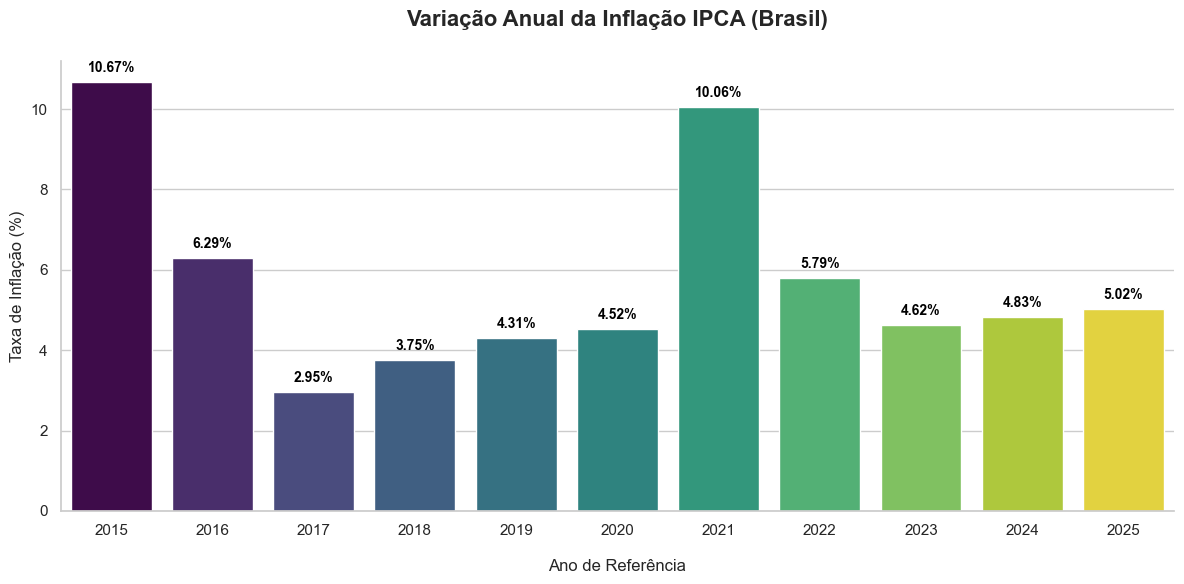

In [37]:
class VisualizadorHistoricoIPCA:
    def __init__(self, dados_inflacao_dict: dict):
        self.df_ipca = pd.DataFrame(
            list(dados_inflacao_dict.items()),
            columns=['Ano', 'Taxa_IPCA']
        )
        sns.set_theme(style="whitegrid")

    def plotar_evolucao_barras(self) -> None:
        plt.figure(figsize=(12, 6))

        ax = sns.barplot(
            data=self.df_ipca,
            x='Ano',
            y='Taxa_IPCA',
            palette='viridis',
            hue='Ano',
            legend=False
        )

        for barra in ax.patches:
            height = barra.get_height()
            ax.annotate(
                f'{height:.2f}%',
                (barra.get_x() + barra.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, color='black', fontweight='bold',
                xytext=(0, 5), textcoords='offset points'
            )

        plt.title('Variação Anual da Inflação IPCA (Brasil)', fontsize=16, fontweight='bold', pad=25)
        plt.xlabel('Ano de Referência', fontsize=12, labelpad=15)
        plt.ylabel('Taxa de Inflação (%)', fontsize=12)

        plt.xticks(rotation=0)
        sns.despine()
        plt.tight_layout()
        plt.show()


# 1. Dados
historico_ipca_bcb = {
    2015: 10.67, 2016: 6.29, 2017: 2.95, 2018: 3.75, 2019: 4.31,
    2020: 4.52, 2021: 10.06, 2022: 5.79, 2023: 4.62, 2024: 4.83, 2025: 5.02
}

visualizador = VisualizadorHistoricoIPCA(historico_ipca_bcb)
visualizador.plotar_evolucao_barras()

#### 2.3.2 Analise do IPCA, Multiplicador de Correção em relação ao Valor

In [38]:

class CalculadoraDeInflacaoIPCA:
    def gerar_relatorio_de_fator_de_correcao(self):
        dados_bcb = {
            2015: 10.67, 2016: 6.29, 2017: 2.95, 2018: 3.75, 2019: 4.31,
            2020: 4.52, 2021: 10.06, 2022: 5.79, 2023: 4.62, 2024: 4.83, 2025: 5.02
        }
        df_ipca = pd.DataFrame(list(dados_bcb.items()), columns=['Ano', 'IPCA_Anual_Percentual'])

        df_ipca['Multiplicador'] = 1 + (df_ipca['IPCA_Anual_Percentual'] / 100)
        df_ipca = df_ipca.sort_values(by='Ano', ascending=False)

        df_ipca['Fator_Correcao'] = df_ipca['Multiplicador'].cumprod().shift(1).fillna(1.0)
        df_ipca = df_ipca.sort_values(by='Ano')

        # Retornando exatamente os nomes criados
        return df_ipca[['Ano', 'IPCA_Anual_Percentual', 'Fator_Correcao']]

class AnalisadorDeEvolucaoRealVsNominalPrecos:
    def __init__(self, dataframe: pd.DataFrame, calculadora_ipca: CalculadoraDeInflacaoIPCA):
        self.dataframe = dataframe.copy()
        self.calculadora_ipca = calculadora_ipca
        self._garantir_coluna_ano()

    def _garantir_coluna_ano(self):
        if 'Ano' not in self.dataframe.columns:
            self.dataframe['Data da Coleta'] = pd.to_datetime(self.dataframe['Data da Coleta'], errors='coerce')
            self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year

    def processar_relatorio_evolucao_do_produto(self, nome_do_produto: str, df_inflacao: pd.DataFrame):
        dados_do_produto = self.dataframe[self.dataframe['Produto'] == nome_do_produto]

        estatatisticas_nominais = (
            dados_do_produto
            .groupby('Ano')['Valor de Venda']
            .agg(Media_Nominal='mean')
            .reset_index()
        )

        tabela_ipca_correcao = pd.merge(estatatisticas_nominais, df_inflacao, on='Ano', how='left')

        # Multiplicando
        tabela_ipca_correcao['Media_Real'] = (tabela_ipca_correcao['Media_Nominal'] * tabela_ipca_correcao['Fator_Correcao']).round(2)

        # Renomear colunas
        tabela_ipca_correcao_renomeada = tabela_ipca_correcao.rename(columns={
            'Media_Nominal': 'Preço na Bomba da Época (R$)',
            'Media_Real': 'Preço Equivalente Hoje (R$)',
            'IPCA_Anual_Percentual': 'Inflação do Ano (%)',
            'Fator_Correcao': 'Multiplicador de Correção'
        }).set_index('Ano').round(2)

        return tabela_ipca_correcao_renomeada

    def exibir_relatorio_ajustados_pela_inflacao(self):
        print("\n" + "-"*70)
        print(" ANÁLISE DE PODER DE COMPRA: PREÇO NOMINAL VS PREÇO REAL (AJUSTADO IPCA)")
        print("-" * 70 + "\n")

        dataFrame_inflacao = self.calculadora_ipca.gerar_relatorio_de_fator_de_correcao()
        produtos_unicos_ordenados = sorted(self.dataframe['Produto'].dropna().unique())

        for produto in produtos_unicos_ordenados:
            print(f"\n ⛽ PRODUTO: {produto}\n")
            relatorio_final = self.processar_relatorio_evolucao_do_produto(produto, dataFrame_inflacao)
            display(relatorio_final)

calculadora_ipca = CalculadoraDeInflacaoIPCA()
analisador_evolucao_real_vs_nominal = AnalisadorDeEvolucaoRealVsNominalPrecos(dataframe_final, calculadora_ipca)
analisador_evolucao_real_vs_nominal.exibir_relatorio_ajustados_pela_inflacao()


----------------------------------------------------------------------
 ANÁLISE DE PODER DE COMPRA: PREÇO NOMINAL VS PREÇO REAL (AJUSTADO IPCA)
----------------------------------------------------------------------


 ⛽ PRODUTO: DIESEL



,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2015.0,2.81,10.67,1.66,4.66
2016.0,3.02,6.29,1.56,4.71
2017.0,3.09,2.95,1.52,4.69
2018.0,3.50,3.75,1.46,5.11
2019.0,3.59,4.31,1.40,5.04
2020.0,3.43,4.52,1.34,4.60
2021.0,4.66,10.06,1.22,5.68
2022.0,6.57,5.79,1.15,7.56
2023.0,5.76,4.62,1.10,6.34



 ⛽ PRODUTO: DIESEL S10



,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2015.0,2.96,10.67,1.66,4.91
2016.0,3.15,6.29,1.56,4.92
2017.0,3.21,2.95,1.52,4.87
2018.0,3.59,3.75,1.46,5.25
2019.0,3.68,4.31,1.40,5.16
2020.0,3.52,4.52,1.34,4.72
2021.0,4.71,10.06,1.22,5.73
2022.0,6.66,5.79,1.15,7.67
2023.0,5.86,4.62,1.10,6.45



 ⛽ PRODUTO: ETANOL



...

,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2015.0,3.35,10.67,1.66,5.55
2016.0,3.72,6.29,1.56,5.81
2017.0,3.76,2.95,1.52,5.71
2018.0,4.45,3.75,1.46,6.50
2019.0,4.42,4.31,1.40,6.19
2020.0,4.29,4.52,1.34,5.75
2021.0,5.82,10.06,1.22,7.09
2022.0,6.29,5.79,1.15,7.24
2023.0,5.54,4.62,1.10,6.10



 ⛽ PRODUTO: GASOLINA ADITIVADA



,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2020.0,4.57,4.52,1.34,6.13
2021.0,5.97,10.06,1.22,7.27
2022.0,6.44,5.79,1.15,7.42
2023.0,5.73,4.62,1.10,6.30
2024.0,6.10,4.83,1.05,6.41
2025.0,6.45,5.02,1.00,6.45



 ⛽ PRODUTO: GNV



,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2015.0,2.03,10.67,1.66,3.37
2016.0,2.26,6.29,1.56,3.53
2017.0,2.35,2.95,1.52,3.57
2018.0,2.72,3.75,1.46,3.97
2019.0,3.21,4.31,1.40,4.50
2020.0,3.17,4.52,1.34,4.25
2021.0,3.86,10.06,1.22,4.70
2022.0,5.03,5.79,1.15,5.80
2023.0,4.66,4.62,1.10,5.13


#### 2.3.3 Análise Visual do IPCA, Multiplicador de Correção no Combustível

Utilizamos um gráfico de linhas duplas com preenchimento de área.

* Uma linha mostrará o Preço Nominal (o valor exato que o motorista pagou na época).
* A outra linha mostrará o Preço Real (aquele valor convertido para o dinheiro de hoje).
* O espaço sombreado entre as duas linhas representará a Corrosão Inflacionária (o poder de compra que foi engolido pela inflação).


--------------------------------------------------------------------------------
 PODER DE COMPRA: PREÇO NOMINAL (NA BOMBA) VS PREÇO REAL (AJUSTADO)
--------------------------------------------------------------------------------



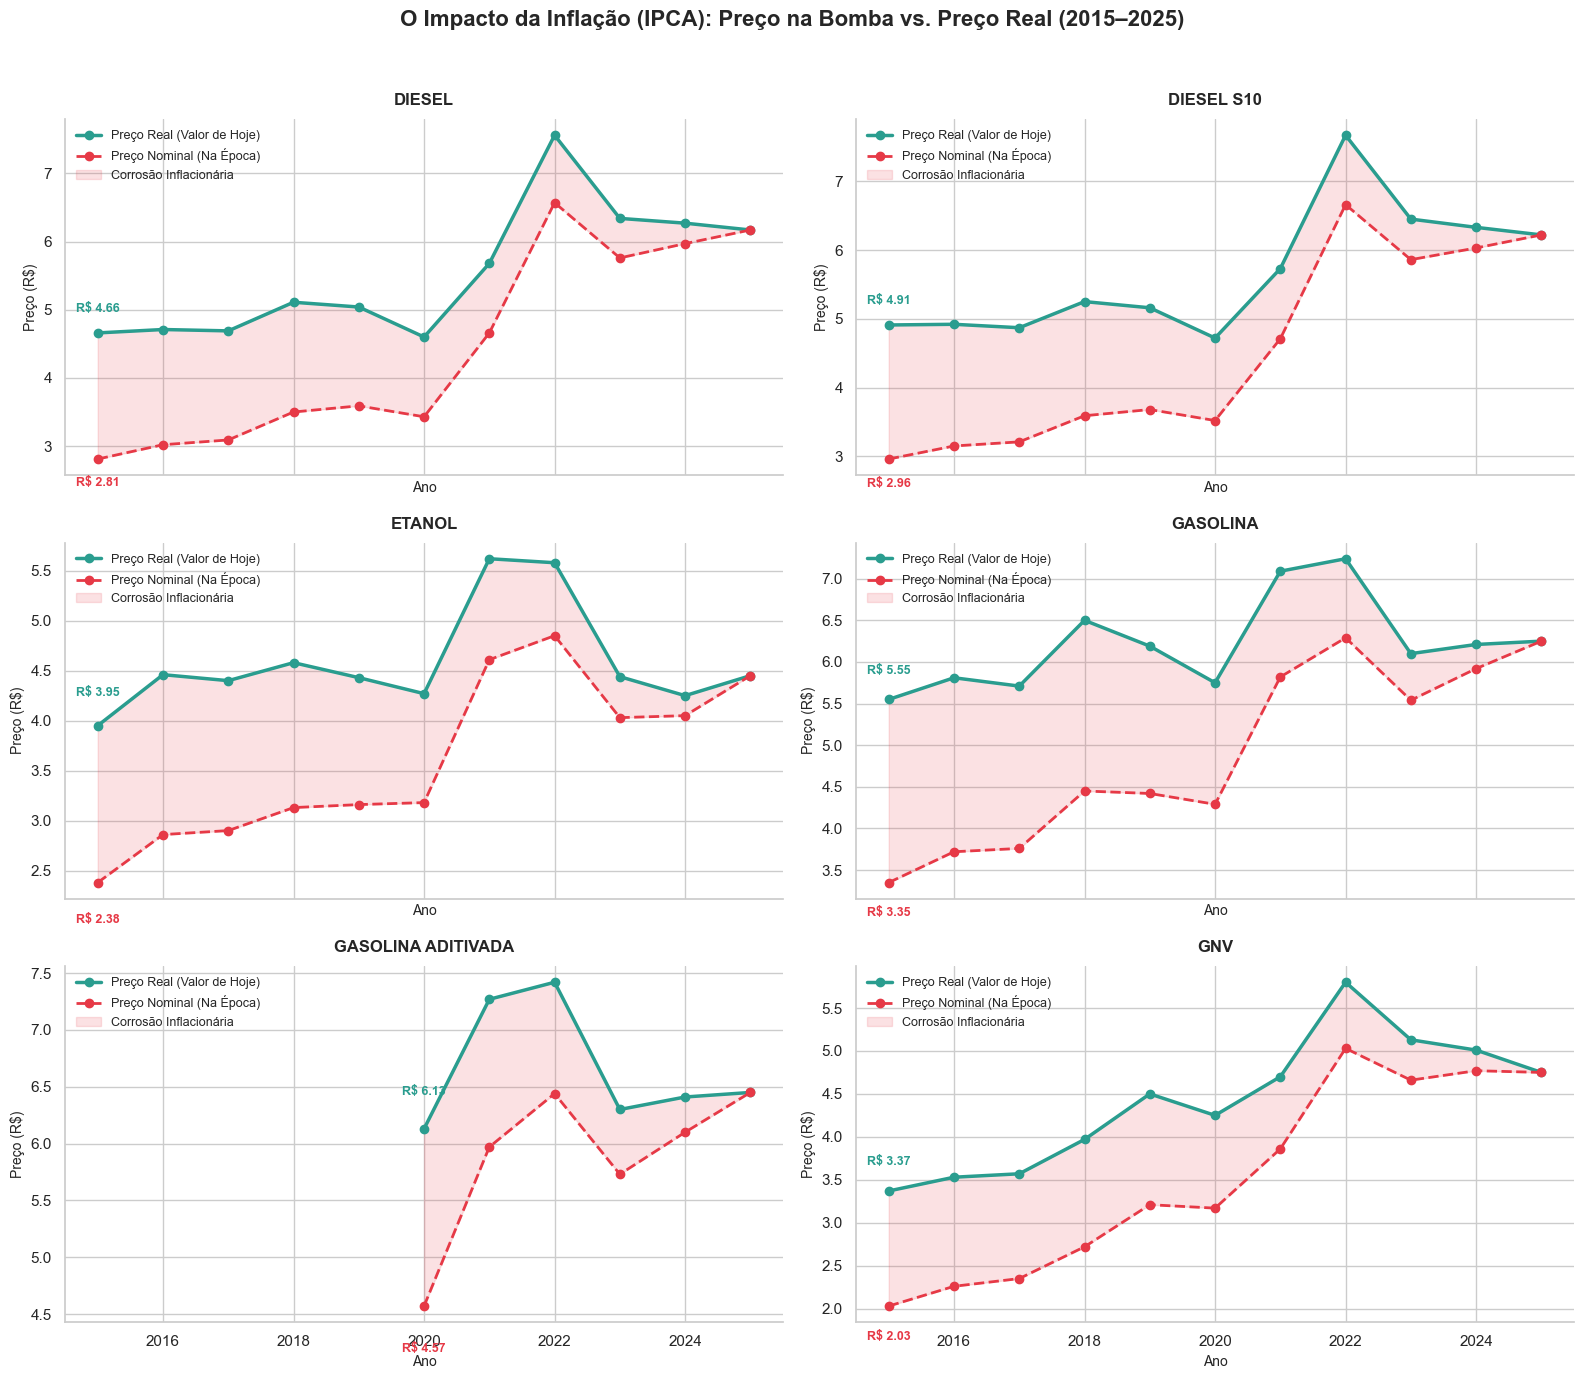

In [39]:

class VisualizadorPoderDeCompra:
    def __init__(self, analisador_evolucao: AnalisadorDeEvolucaoRealVsNominalPrecos):
        self.analisador = analisador_evolucao
        self.df_inflacao = self.analisador.calculadora_ipca.gerar_relatorio_de_fator_de_correcao()
        self._configurar_estilo()

    def _configurar_estilo(self):
        sns.set_theme(style="whitegrid")
        plt.rcParams["axes.titlesize"] = 12
        plt.rcParams["axes.labelsize"] = 10

    def plotar_comparativo_real_vs_nominal(self):
        print("\n" + "-"*80)
        print(" PODER DE COMPRA: PREÇO NOMINAL (NA BOMBA) VS PREÇO REAL (AJUSTADO)")
        print("-"*80 + "\n")

        produtos = sorted(self.analisador.dataframe['Produto'].dropna().unique())
        qtd_produtos = len(produtos)

        cols = 2
        rows = (qtd_produtos + 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4.5), sharex=True)
        axes = axes.flatten()

        fig.suptitle('O Impacto da Inflação (IPCA): Preço na Bomba vs. Preço Real (2015–2025)',
                     fontsize=16, fontweight='bold', y=1.02)

        for i, produto in enumerate(produtos):
            ax = axes[i]

            df_calc = self.analisador.processar_relatorio_evolucao_do_produto(produto, self.df_inflacao)
            anos = df_calc.index
            preco_nominal = df_calc['Preço na Bomba da Época (R$)']
            preco_real = df_calc['Preço Equivalente Hoje (R$)']

            ax.plot(anos, preco_real, marker='o', color='#2A9D8F', linewidth=2.5, label='Preço Real (Valor de Hoje)')
            ax.plot(anos, preco_nominal, marker='o', color='#E63946', linewidth=2, linestyle='--', label='Preço Nominal (Na Época)')
            ax.fill_between(anos, preco_nominal, preco_real, color='#E63946', alpha=0.15, label='Corrosão Inflacionária')
            ax.text(anos[0], preco_real.iloc[0] + 0.3, f"R$ {preco_real.iloc[0]:.2f}", color='#2A9D8F', fontweight='bold', ha='center', fontsize=9)
            ax.text(anos[0], preco_nominal.iloc[0] - 0.4, f"R$ {preco_nominal.iloc[0]:.2f}", color='#E63946', fontweight='bold', ha='center', fontsize=9)

            ax.set_title(produto, fontweight='bold', pad=10)
            ax.set_ylabel('Preço (R$)')
            ax.set_xlabel('Ano')
            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
            ax.legend(fontsize=9, loc='upper left', frameon=False)
            sns.despine(ax=ax)

        for j in range(qtd_produtos, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

visualizador_poder_compra = VisualizadorPoderDeCompra(analisador_evolucao_real_vs_nominal)
visualizador_poder_compra.plotar_comparativo_real_vs_nominal()

## 3.0 Análise de Distribuições e Visualizações

### 3.1.0 Criação da preparação Visual

In [40]:
class GerenciadorDeConfiguracaoVisual:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        self._aplicar_identidade_visual_do_projeto()

    def _aplicar_identidade_visual_do_projeto(self) -> None:
        sns.set_theme(style="whitegrid", palette="muted")
        plt.rcParams["figure.figsize"] = (12, 5)
        plt.rcParams["axes.titlesize"] = 14
        plt.rcParams["axes.labelsize"] = 12
        plt.rcParams["axes.titleweight"] = "bold"

    def extrair_amostra_otimizada(self, tamanho_da_amostra: int = 50000) -> pd.DataFrame:
        if len(self.dataframe) <= tamanho_da_amostra:
            return self.dataframe.copy()
        return self.dataframe.sample(n=tamanho_da_amostra, random_state=42)

    def filtrar_pelos_principais_produtos(self, dataframe_alvo: pd.DataFrame, top_n: int = 4) -> pd.DataFrame:
        produtos_mais_frequentes = self.dataframe['Produto'].value_counts().head(top_n).index
        dataframe_filtrado = dataframe_alvo[dataframe_alvo['Produto'].isin(produtos_mais_frequentes)]
        return dataframe_filtrado

configurador_visual = GerenciadorDeConfiguracaoVisual(dataframe_final)
df_amostra_leve = configurador_visual.extrair_amostra_otimizada(tamanho_da_amostra=50000)
df_pronto_para_graficos = configurador_visual.filtrar_pelos_principais_produtos(df_amostra_leve, top_n=4)

### 3.2.0 Visualização das Análises Descritivas

#### 3.2.1 Visualização Descritiva do Valor de Vendas Por Produto e Estado

As visualizações a seguir complementam a análise estatística descritiva apresentada anteriormente, permitindo uma leitura visual do comportamento dos preços de venda dos combustíveis no Brasil entre 2015 e 2025, segmentados por tipo de produto e unidade federativa.

* Os valores apresentados são preços nominais, sem ajuste inflacionário (IPCA)

#### 3.2.2 Gráfico 1 - Heatmap & Gráfico 2 - Barras 

* **Gráfico 1**: Permite identificar visualmente quais estados praticam os maiores e menores preços médios para cada tipo de combustível, facilitando a comparação regional.
* **Gráfico 2**: Apresenta o preço médio geral de cada combustível considerando todos os estados, acompanhado do desvio padrão, indicando o grau de variação dos preços no período analisado.


--------------------------------------------------------------------------------
 GRÁFICO 1: HEATMAP - PREÇO MÉDIO POR PRODUTO E ESTADO
--------------------------------------------------------------------------------



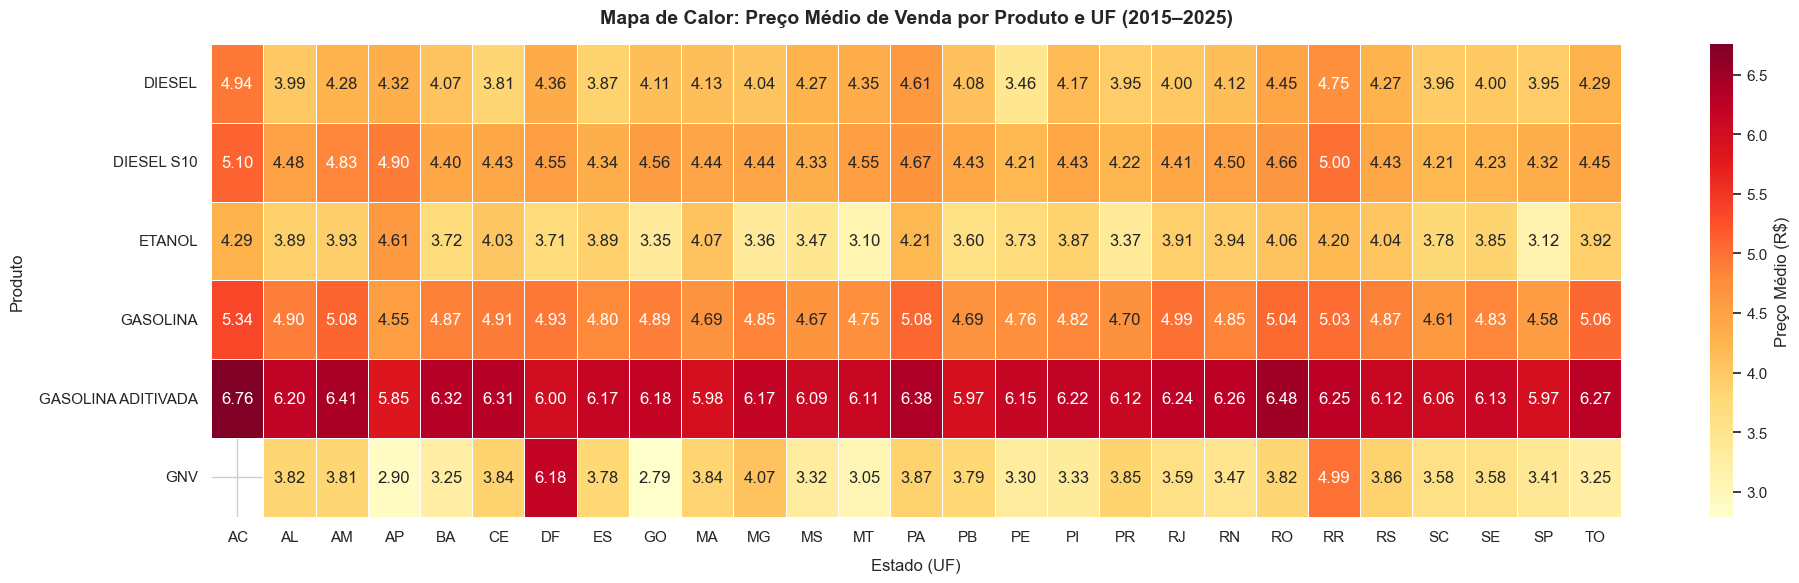


--------------------------------------------------------------------------------
 GRÁFICO 2: PREÇO MÉDIO NACIONAL COM DESVIO PADRÃO (VARIAÇÃO)
--------------------------------------------------------------------------------



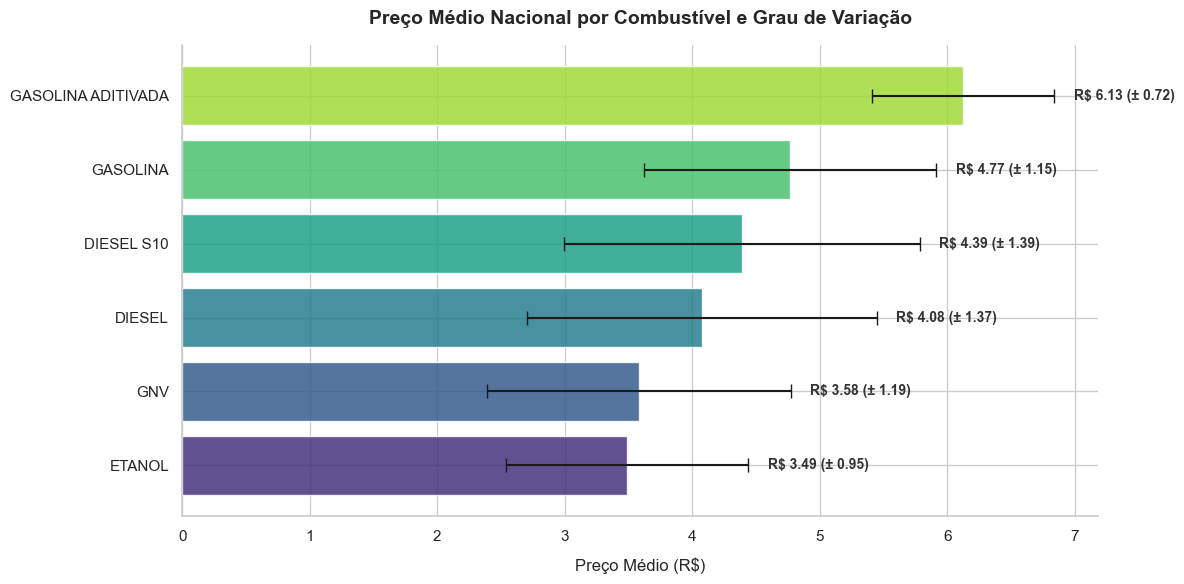

In [41]:
class VisualizadorDescritivoDePrecos:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        self._configurar_estilo()

    def _configurar_estilo(self):
        sns.set_theme(style="whitegrid", palette="muted")
        plt.rcParams["axes.titlesize"] = 14
        plt.rcParams["axes.labelsize"] = 12

    def plotar_heatmap_media_por_estado(self):
        print("\n" + "-"*80)
        print(" GRÁFICO 1: HEATMAP - PREÇO MÉDIO POR PRODUTO E ESTADO")
        print("-"*80 + "\n")

        pivot_media = (
            self.dataframe
            .groupby(['Produto', 'Estado - Sigla'])['Valor de Venda']
            .mean()
            .unstack(level='Estado - Sigla')
        )

        fig, ax = plt.subplots(figsize=(20, 6))
        sns.heatmap(
            pivot_media,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Preço Médio (R$)'}
        )

        ax.set_title('Mapa de Calor: Preço Médio de Venda por Produto e UF (2015–2025)', fontweight='bold', pad=15)
        ax.set_xlabel('Estado (UF)', labelpad=10)
        ax.set_ylabel('Produto', labelpad=10)

        plt.tight_layout()
        plt.show()

    def plotar_barras_media_com_desvio(self):
        print("\n" + "-"*80)
        print(" GRÁFICO 2: PREÇO MÉDIO NACIONAL COM DESVIO PADRÃO (VARIAÇÃO)")
        print("-"*80 + "\n")

        estatisticas_nacionais = (
            self.dataframe
            .groupby('Produto')['Valor de Venda']
            .agg(['mean', 'std'])
            .sort_values('mean', ascending=True)
        )

        fig, ax = plt.subplots(figsize=(12, 6))

        bars = ax.barh(
            estatisticas_nacionais.index,
            estatisticas_nacionais['mean'],
            xerr=estatisticas_nacionais['std'], # Linha de Desvio Padrão
            color=sns.color_palette("viridis", len(estatisticas_nacionais)), # Paleta dinâmica
            edgecolor='white',
            capsize=5,
            alpha=0.85
        )

        ax.set_title('Preço Médio Nacional por Combustível e Grau de Variação', fontweight='bold', pad=15)
        ax.set_xlabel('Preço Médio (R$)', labelpad=10)
        ax.set_ylabel('')

        for i, (bar, media, desvio) in enumerate(zip(bars, estatisticas_nacionais['mean'], estatisticas_nacionais['std'])):
            posicao_x_texto = media + desvio + 0.15

            ax.text(
                posicao_x_texto,
                bar.get_y() + bar.get_height() / 2,
                f'R$ {media:.2f} (± {desvio:.2f})',
                va='center',
                fontsize=10,
                fontweight='bold',
                color='#333333'
            )

        sns.despine()
        plt.tight_layout()
        plt.show()

    def gerar_painel_visual_completo(self) -> None:
        self.plotar_heatmap_media_por_estado()
        self.plotar_barras_media_com_desvio()

viz_descritivo = VisualizadorDescritivoDePrecos(dataframe_final)
viz_descritivo.gerar_painel_visual_completo()

#### 3.2.3 Ranking dos Municípios Mais Caros e Mais Baratos

Para cada tipo de combustível, são exibidos os 5 municípios com maior preço médio e os 5 com menor preço médio no período de 2015 a 2025.

* Valores nominais, sem ajuste por IPCA.


--------------------------------------------------------------------------------
 RANKING: TOP 10 MUNICÍPIOS MAIS CAROS E MAIS BARATOS POR PRODUTO
--------------------------------------------------------------------------------



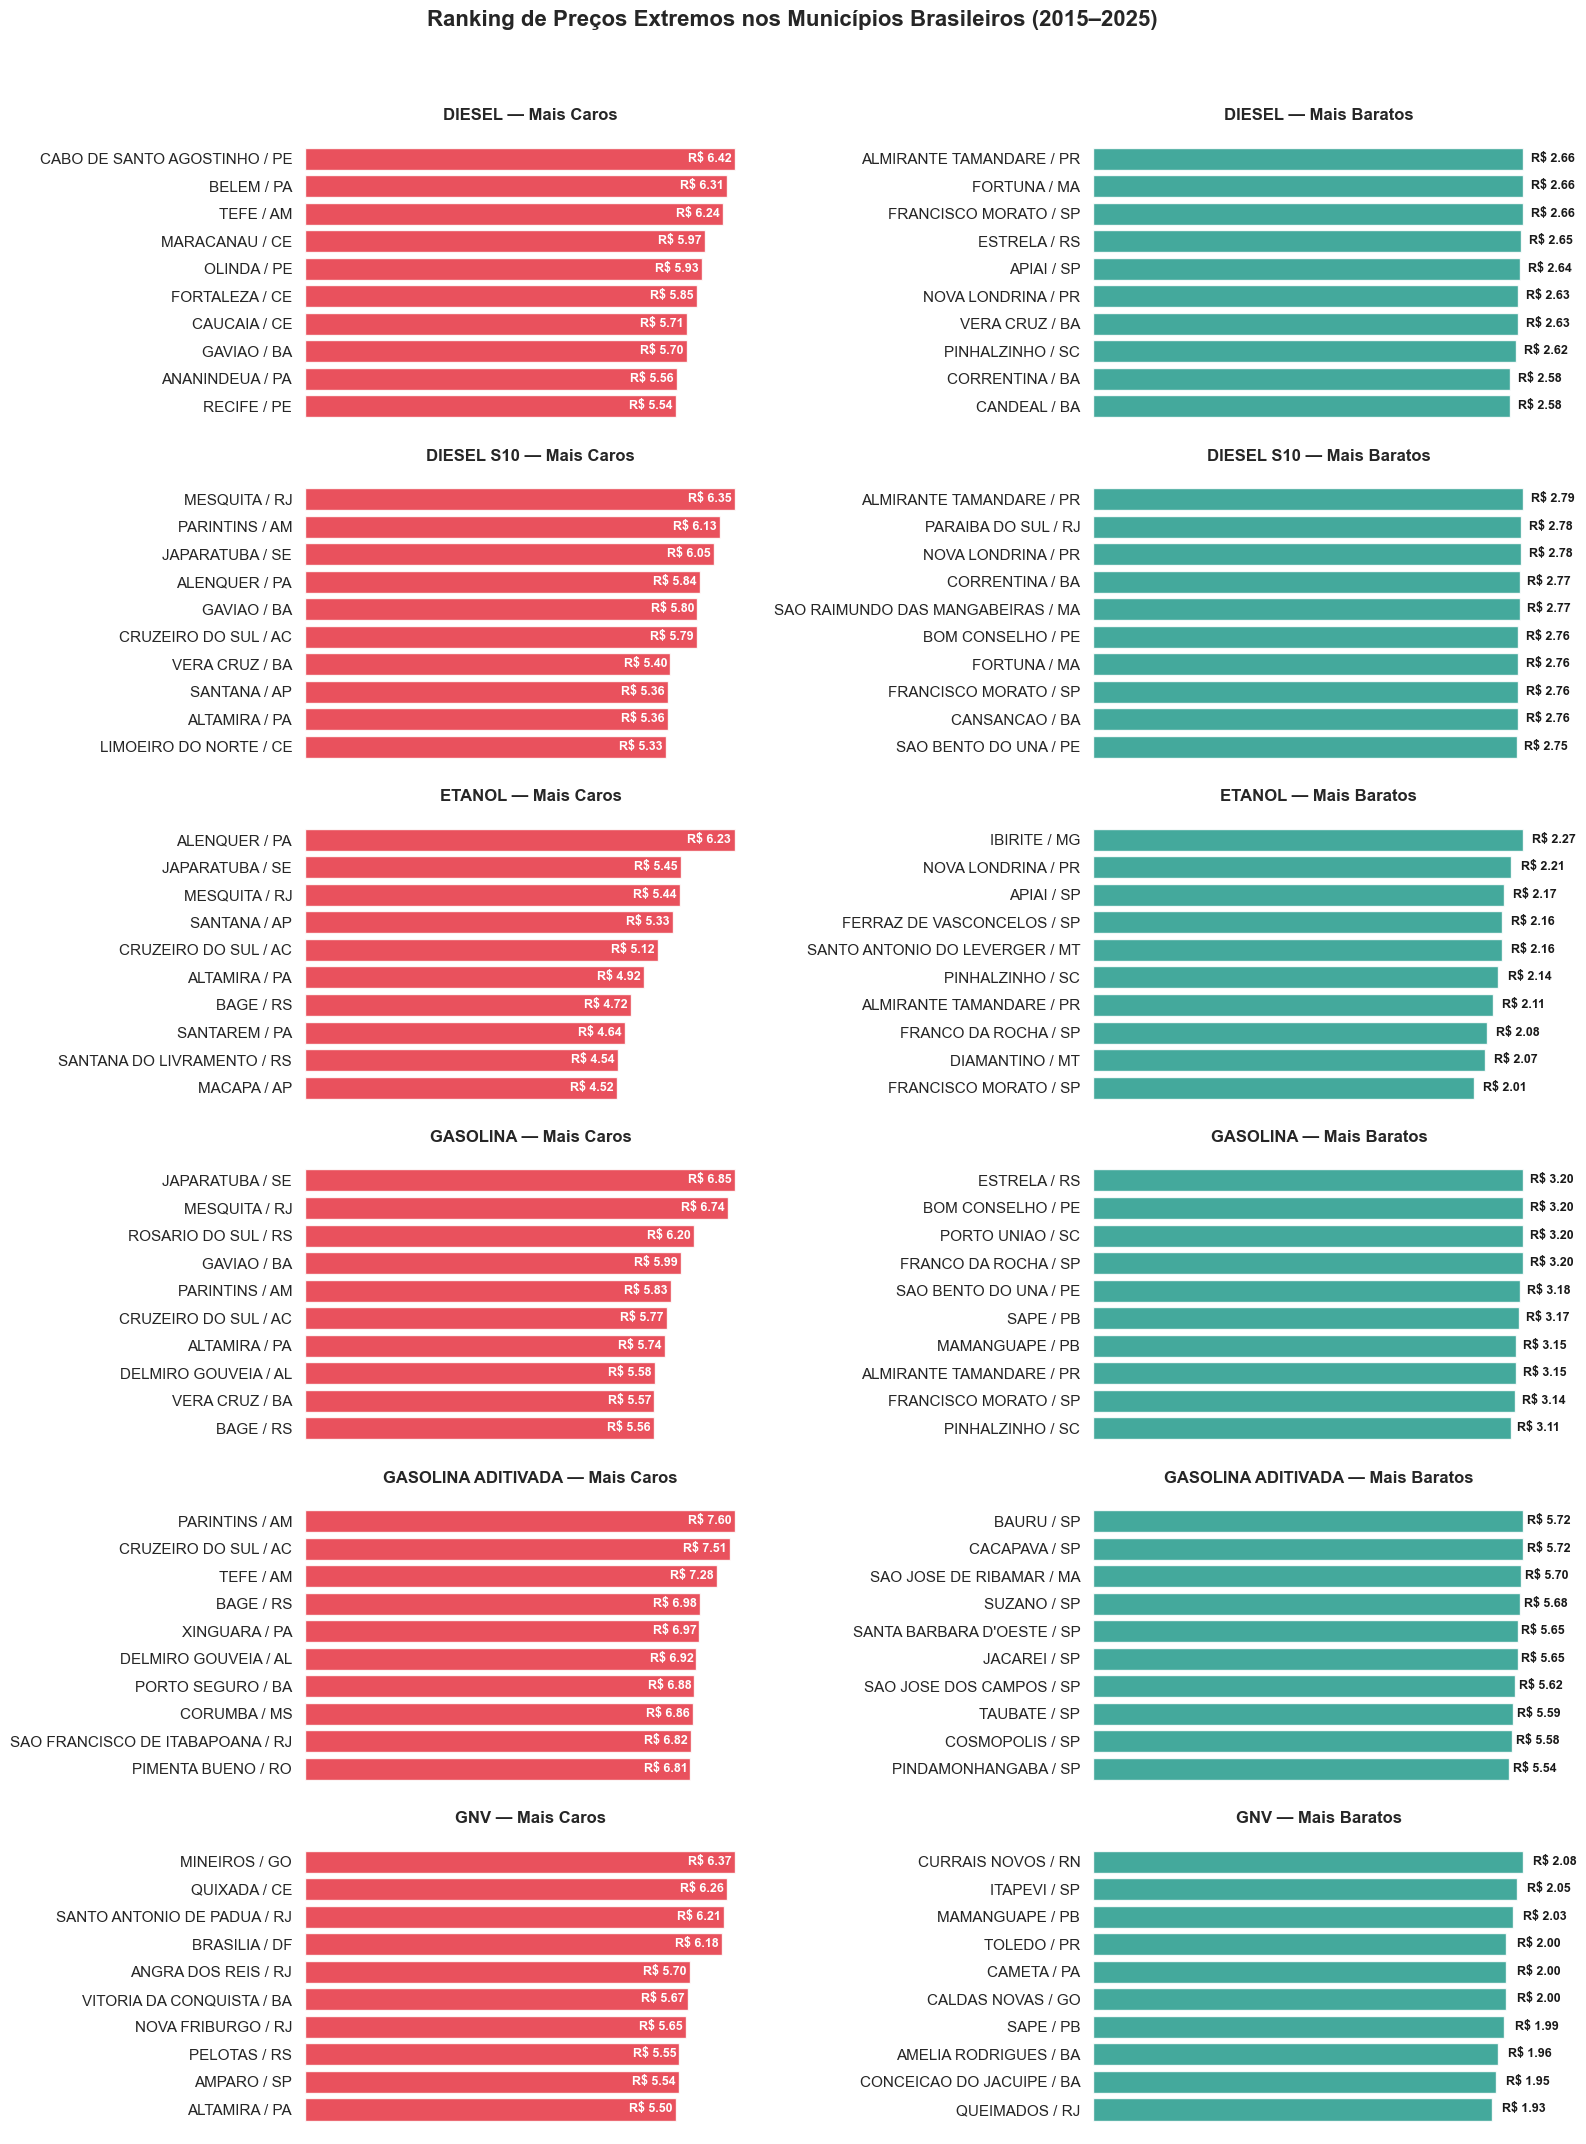

In [42]:
class VisualizadorMunicipiosPorProdutoPrecos:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        self._configurar_estilo()

    def _configurar_estilo(self):
        sns.set_theme(style="whitegrid")
        plt.rcParams["axes.titlesize"] = 12
        plt.rcParams["axes.labelsize"] = 10

    def _calcular_media_por_municipio(self):
        return (
            self.dataframe
            .groupby(['Produto', 'Estado - Sigla', 'Municipio'])['Valor de Venda']
            .mean()
            .round(2)
            .reset_index()
        )

    def _desenhar_painel_de_barras(self, ax, df_dados, cor, titulo, texto_interno=True):

        labels = df_dados['Municipio'] + ' / ' + df_dados['Estado - Sigla']
        valores = df_dados['Valor de Venda']

        ax.barh(labels, valores, color=cor, edgecolor='white', alpha=0.88)
        ax.set_title(titulo, fontweight='bold', pad=10)
        ax.invert_yaxis() # O maior valor fica no topo
        ax.set_xticks([])
        ax.set_xlabel('')
        ax.grid(False)

        for j, val in enumerate(valores):
            if texto_interno:
                ax.text(val - 0.05, j, f'R$ {val:.2f}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')
            else:
                ax.text(val + 0.05, j, f'R$ {val:.2f}', va='center', ha='left', fontsize=9, color='#1a1a1a', fontweight='bold')

        sns.despine(ax=ax, left=True, bottom=True)

    def plotar_ranking_municipios_por_produto(self):
        print("\n" + "-"*80)
        print(" RANKING: TOP 10 MUNICÍPIOS MAIS CAROS E MAIS BARATOS POR PRODUTO")
        print("-"*80 + "\n")

        dados = self._calcular_media_por_municipio()
        produtos = sorted(dados['Produto'].unique())
        qtd_produtos = len(produtos)

        fig, axes = plt.subplots(qtd_produtos, 2, figsize=(16, qtd_produtos * 3.5))
        fig.suptitle('Ranking de Preços Extremos nos Municípios Brasileiros (2015–2025)', fontsize=16, fontweight='bold', y=1.02)

        if qtd_produtos == 1: axes = [axes]

        for i, produto in enumerate(produtos):
            df_produto = dados[dados['Produto'] == produto].sort_values('Valor de Venda', ascending=False)

            top_caros = df_produto.head(10).copy()
            top_baratos = df_produto.tail(10).copy() # Pega os 5 últimos

            self._desenhar_painel_de_barras(
                ax=axes[i, 0],
                df_dados=top_caros,
                cor='#E63946',
                titulo=f'{produto} — Mais Caros',
                texto_interno=True
            )

            self._desenhar_painel_de_barras(
                ax=axes[i, 1],
                df_dados=top_baratos,
                cor='#2A9D8F',
                titulo=f'{produto} — Mais Baratos',
                texto_interno=False
            )

        plt.tight_layout()
        plt.show()

    def gerar_visualizacoes_completas(self):
        self.plotar_ranking_municipios_por_produto()


viz_municipios = VisualizadorMunicipiosPorProdutoPrecos(dataframe_final)
viz_municipios.gerar_visualizacoes_completas()

#### 3.2.4 Evolução Bruta dos Preços dos Combustíveis (2015 - 2025)

O gráfico abaixo apresenta a evolução do preço médio anual de cada combustível, acompanhada da faixa entre o menor e o maior preço registrado no período. Isso permite observar tanto a tendência geral quanto a volatilidade dos preços ao longo dos anos.

* Valores nominais, sem ajuste por IPCA.


--------------------------------------------------------------------------------
 EVOLUÇÃO TEMPORAL: PREÇO MÉDIO E AMPLITUDE (MÍN/MÁX)
--------------------------------------------------------------------------------



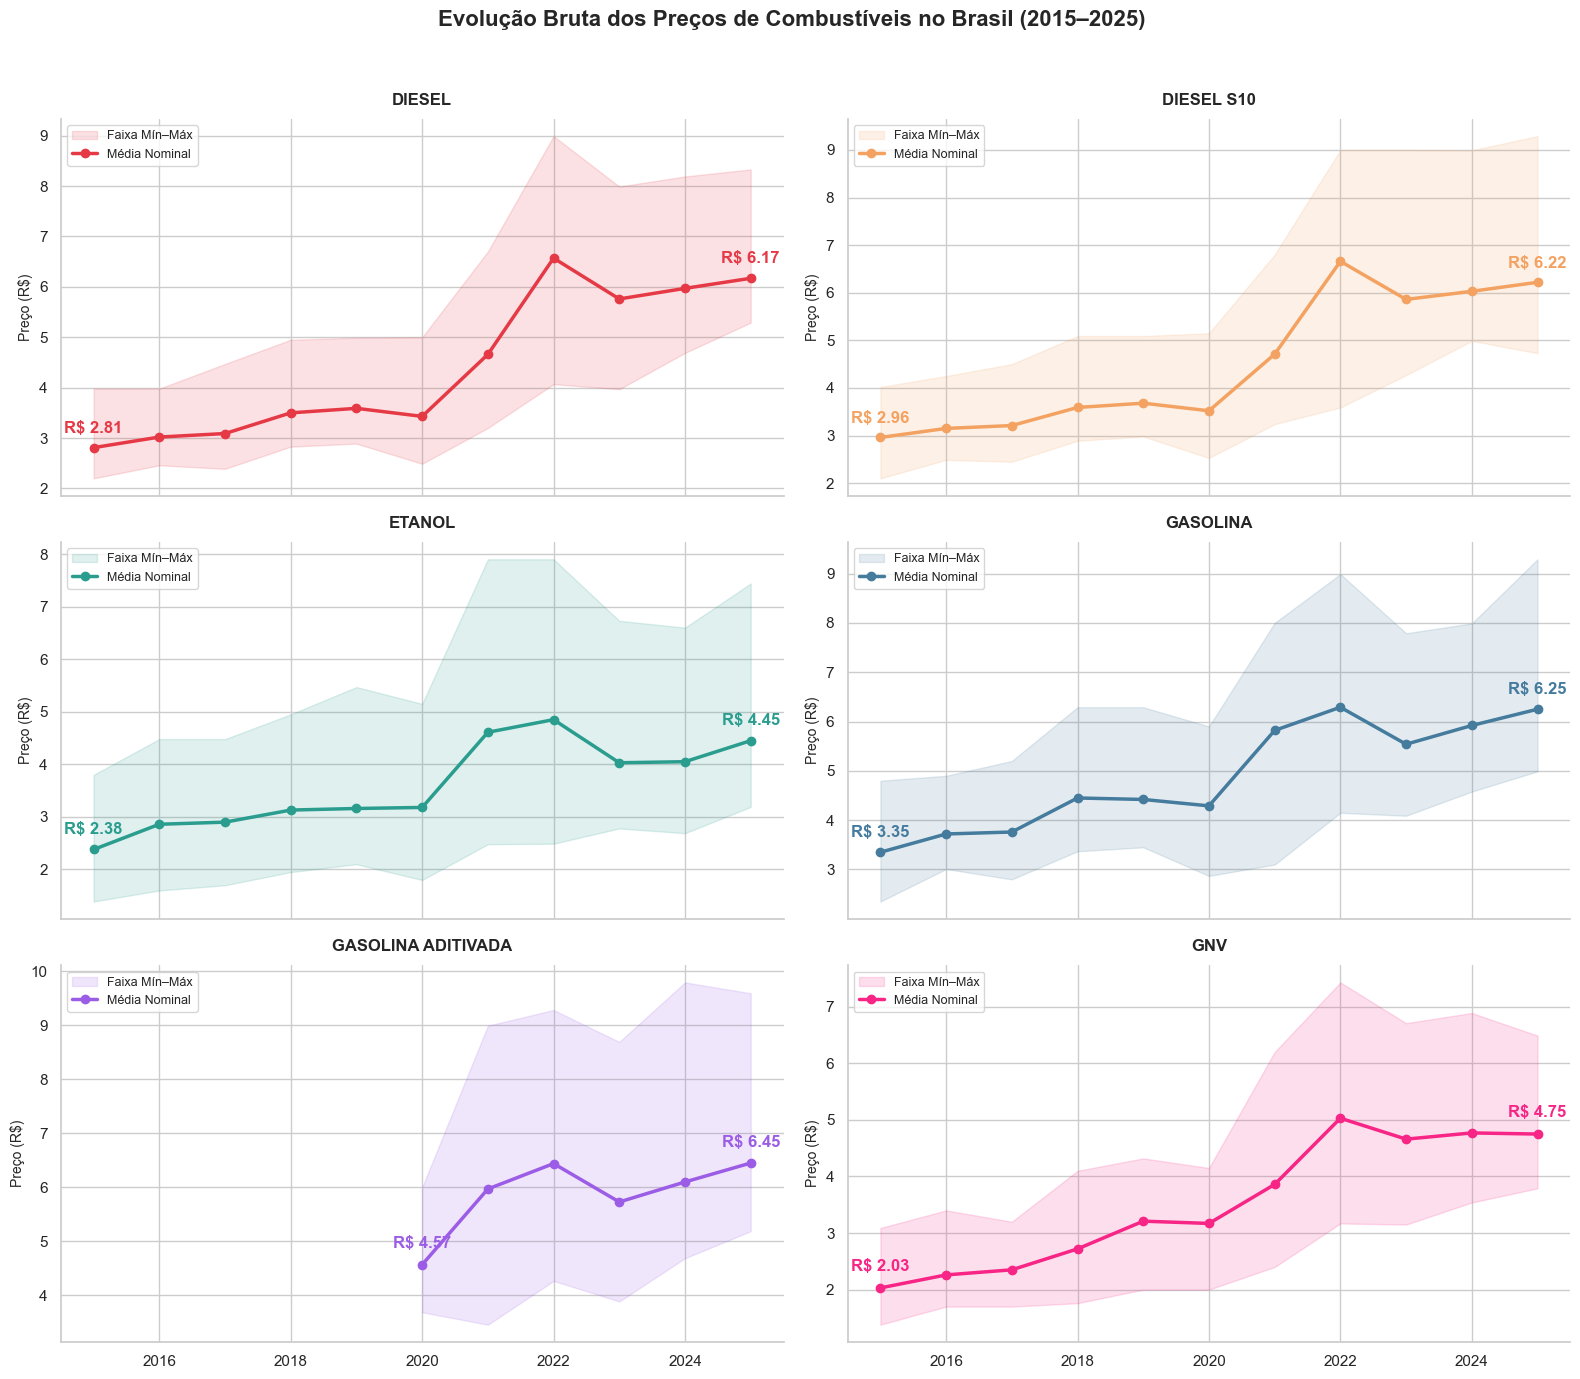

In [43]:

class VisualizadorEvolucaoTemporalPrecos:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.copy()
        self._preparar_dados()
        self._configurar_estilo()

    def _configurar_estilo(self):
        sns.set_theme(style="whitegrid")
        plt.rcParams["axes.titlesize"] = 12
        plt.rcParams["axes.labelsize"] = 10

    def _preparar_dados(self):
        if 'Ano' not in self.dataframe.columns:
            self.dataframe['Data da Coleta'] = pd.to_datetime(
                self.dataframe['Data da Coleta'], errors='coerce'
            )
            self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year

    def _calcular_evolucao(self) -> pd.DataFrame:
        return (
            self.dataframe
            .groupby(['Ano', 'Produto'])['Valor de Venda']
            .agg(Media='mean', Min='min', Max='max')
            .round(2)
            .reset_index()
        )

    def plotar_evolucao_temporal(self) -> None:
        print("\n" + "-"*80)
        print(" EVOLUÇÃO TEMPORAL: PREÇO MÉDIO E AMPLITUDE (MÍN/MÁX)")
        print("-"*80 + "\n")

        dados = self._calcular_evolucao()
        produtos = sorted(dados['Produto'].unique())
        qtd_produtos = len(produtos)

        cores = ['#E63946', '#F4A261', '#2A9D8F', '#457B9D', '#9B5DE5', '#F72585']
        cols = 2
        rows = (qtd_produtos + 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4.5), sharex=True)
        axes = axes.flatten()

        fig.suptitle('Evolução Bruta dos Preços de Combustíveis no Brasil (2015–2025)',
                     fontsize=16, fontweight='bold', y=1.02)

        for i, produto in enumerate(produtos):
            df_p = dados[dados['Produto'] == produto].sort_values('Ano')
            cor  = cores[i % len(cores)]
            ax   = axes[i]

            ax.fill_between(df_p['Ano'], df_p['Min'], df_p['Max'],
                            alpha=0.15, color=cor, label='Faixa Mín–Máx')

            ax.plot(df_p['Ano'], df_p['Media'], marker='o', color=cor,
                    linewidth=2.5, label='Média Nominal')

            primeiro_ano = df_p.iloc[0]
            ultimo_ano = df_p.iloc[-1]

            ax.text(primeiro_ano['Ano'], primeiro_ano['Media'] + 0.3, f"R$ {primeiro_ano['Media']:.2f}",
                    color=cor, fontweight='bold', ha='center')
            ax.text(ultimo_ano['Ano'], ultimo_ano['Media'] + 0.3, f"R$ {ultimo_ano['Media']:.2f}",
                    color=cor, fontweight='bold', ha='center')

            ax.set_title(produto, fontweight='bold', pad=10)
            ax.set_ylabel('Preço (R$)')
            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
            ax.legend(fontsize=9, loc='upper left')
            sns.despine(ax=ax)

        for j in range(qtd_produtos, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    def gerar_visualizacoes_completas(self) -> None:
        self.plotar_evolucao_temporal()

viz_evolucao = VisualizadorEvolucaoTemporalPrecos(dataframe_final)
viz_evolucao.gerar_visualizacoes_completas()

#### 3.2.5 Evolução dos Preços por Região (2015 - 2025)

Complementando a análise temporal, o gráfico abaixo segmenta a evolução dos preços médios por região brasileira, evidenciando que o aumento dos preços não ocorreu de forma homogênea no país — com diferenças regionais relevantes ao longo do período.

* Valores nominais, sem ajuste por IPCA.


--------------------------------------------------------------------------------
 EVOLUÇÃO TEMPORAL: DISPARIDADE DE PREÇOS ENTRE AS REGIÕES DO BRASIL
--------------------------------------------------------------------------------



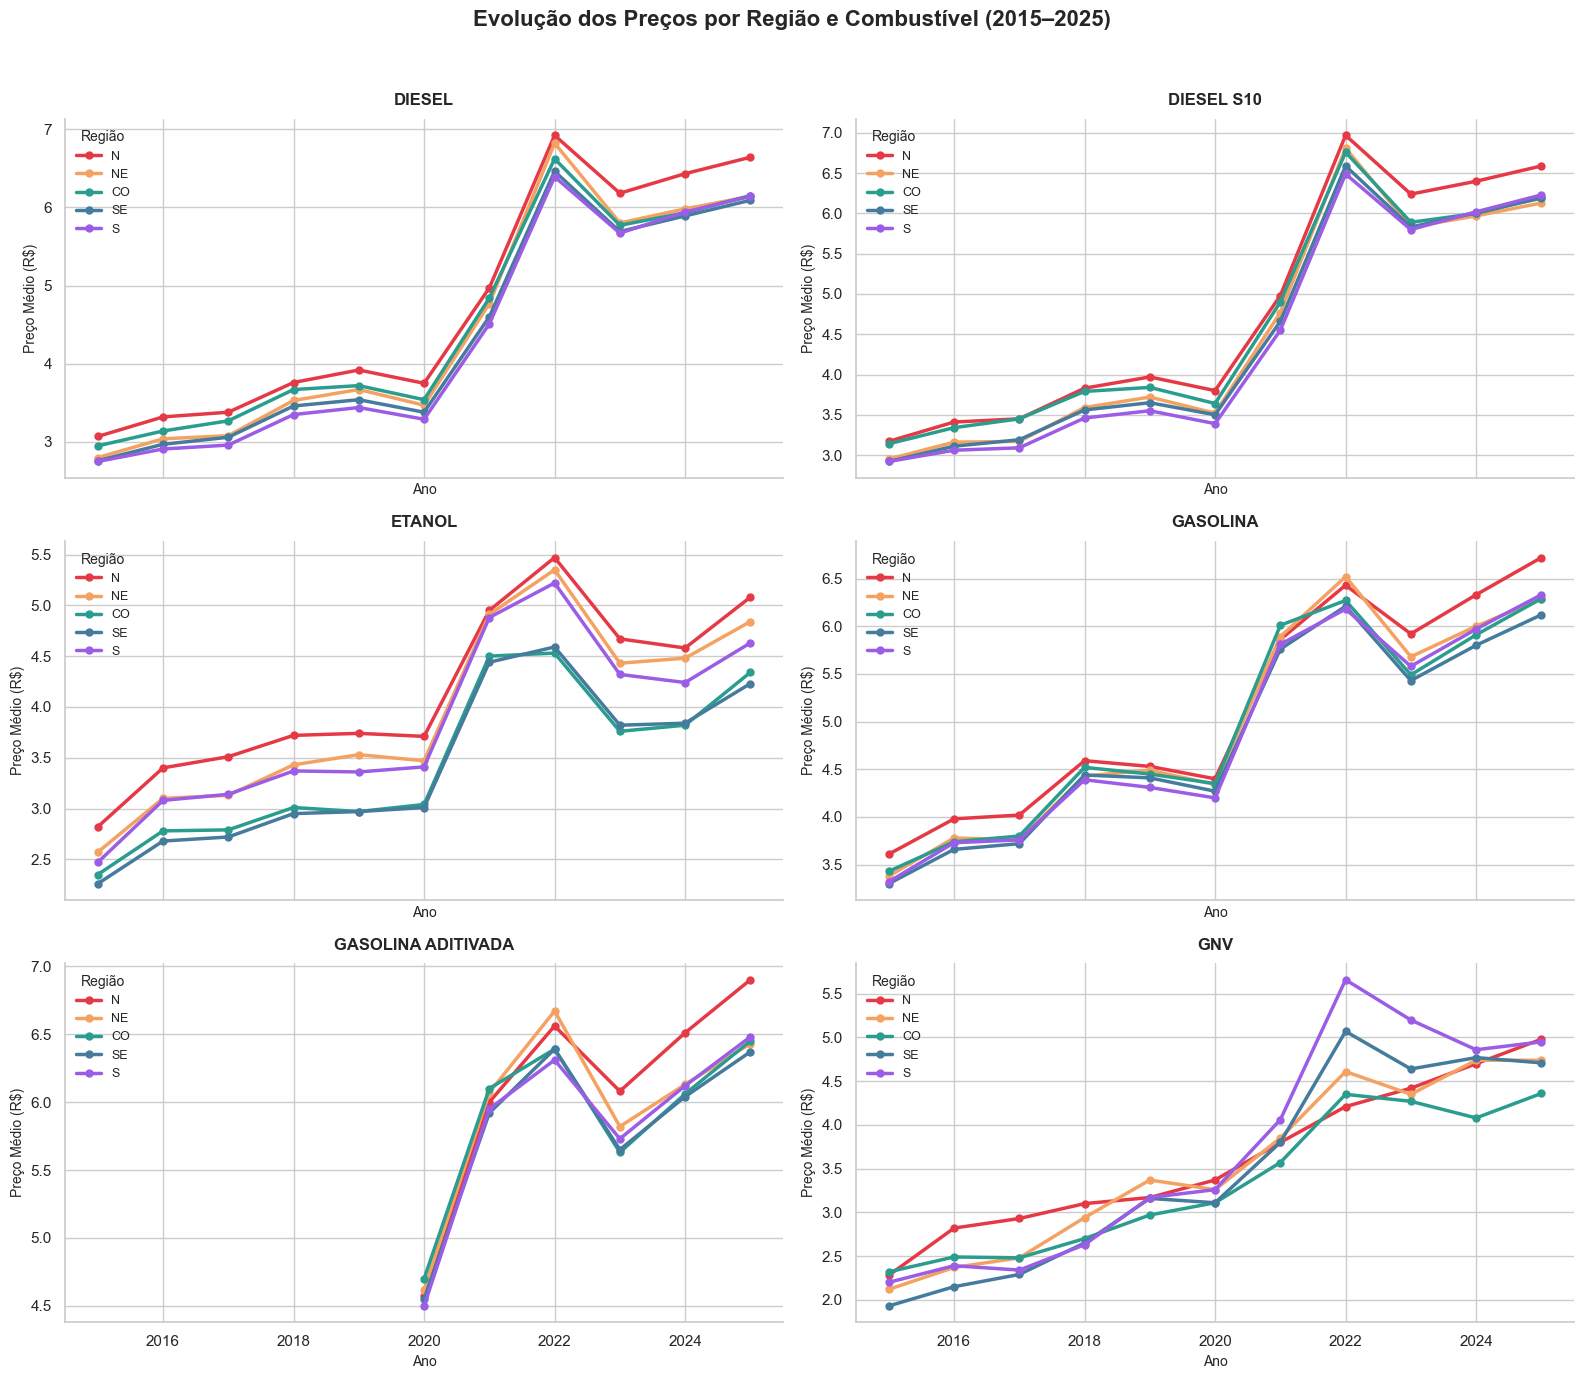

In [44]:

class VisualizadorEvolucaoTemporalPorRegiao:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.copy()
        self._preparar_dados()
        self._configurar_estilo()

    def _configurar_estilo(self):
        sns.set_theme(style="whitegrid")
        plt.rcParams["axes.titlesize"] = 12
        plt.rcParams["axes.labelsize"] = 10

    def _preparar_dados(self):
        if 'Ano' not in self.dataframe.columns:
            self.dataframe['Data da Coleta'] = pd.to_datetime(
                self.dataframe['Data da Coleta'], errors='coerce'
            )
            self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year

    def _calcular_evolucao_por_regiao(self):
        return (
            self.dataframe
            .groupby(['Ano', 'Produto', 'Regiao - Sigla'])['Valor de Venda']
            .mean()
            .round(2)
            .reset_index()
        )

    def plotar_evolucao_por_regiao(self):
        print("\n" + "-"*80)
        print(" EVOLUÇÃO TEMPORAL: DISPARIDADE DE PREÇOS ENTRE AS REGIÕES DO BRASIL")
        print("-"*80 + "\n")

        dados = self._calcular_evolucao_por_regiao()
        produtos = sorted(dados['Produto'].unique())
        qtd_produtos = len(produtos)

        cores_regioes = {
            'N':  '#E63946', # Vermelho
            'NE': '#F4A261', # Laranja
            'CO': '#2A9D8F', # Verde
            'SE': '#457B9D', # Azul
            'S':  '#9B5DE5'  # Roxo
        }

        cols = 2
        rows = (qtd_produtos + 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4.5), sharex=True)
        axes = axes.flatten()

        fig.suptitle('Evolução dos Preços por Região e Combustível (2015–2025)',
                     fontsize=16, fontweight='bold', y=1.02)

        for i, produto in enumerate(produtos):
            ax = axes[i]
            df_p = dados[dados['Produto'] == produto]

            for regiao, cor in cores_regioes.items():
                df_r = df_p[df_p['Regiao - Sigla'] == regiao].sort_values('Ano')

                if df_r.empty:
                    continue

                ax.plot(df_r['Ano'], df_r['Valor de Venda'],
                        marker='o', markersize=5, color=cor, linewidth=2.5,
                        label=regiao)

            ax.set_title(produto, fontweight='bold', pad=10)
            ax.set_ylabel('Preço Médio (R$)')
            ax.set_xlabel('Ano')

            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
            ax.legend(title='Região', fontsize=9, title_fontsize=10, frameon=False, loc='upper left')
            sns.despine(ax=ax)

        for j in range(qtd_produtos, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    def gerar_visualizacoes_completas(self):
        self.plotar_evolucao_por_regiao()

viz_evolucao_regiao = VisualizadorEvolucaoTemporalPorRegiao(dataframe_final)
viz_evolucao_regiao.gerar_visualizacoes_completas()

## 4.0. Identificação de Problemas nos Dados

Durante a análise exploratória dos dados, foram identificados alguns desafios e limitações que podem impactar tanto a interpretação dos resultados quanto o desempenho de modelos preditivos.

### 4.1.0 Desbalancemaneto de Dados

Observa-se um desbalanceamento significativo na distribuição dos dados, tanto em relação aos tipos de combustível quanto às regiões geográficas:

* **Tipo de combustível**: A categoria gasolina aditivada só passa a aparecer com frequência a partir de 2020, o que pode comprometer análises temporais e gerar viés em modelos que considerem períodos anteriores.

* **Distribuição regional**: Há uma forte concentração de dados na região Sudeste, enquanto regiões como Norte e Centro-Oeste possuem menor representatividade:

In [45]:
analisador_regional.gerar_relatorio_completo_distribuidor_regional()


FREQUÊNCIA ABSOLUTA REGIONAL:


,Quantidade de Registros
Região,
SE,4805520
NE,1948525
S,1671048
CO,842951
N,612690


 

FREQUÊNCIA PERCENTUAL REGIONAL:


,Percentual (%)
Região,
SE,48.64
NE,19.72
S,16.91
CO,8.53
N,6.20


* Esse desbalanceamento pode levar o modelo a aprender padrões mais representativos de determinadas regiões, reduzindo sua capacidade de generalização.

### 4.2.0 Ausência de Correção Monetária

Os valores de venda dos combustíveis não estão ajustados pela inflação ao longo do tempo.

Considerando que o período analisado (2015–2025) inclui variações econômicas significativas, a comparação direta dos preços pode levar a interpretações equivocadas. Idealmente, os valores deveriam ser corrigidos por índices inflacionários (como IPCA) para permitir análises mais consistentes.

### 4.3.0 Presença de Outliers e Eventos Exógenos

Foram identificados valores atípicos (outliers) que não necessariamente representam erros, mas sim reflexos de eventos econômicos e sociais relevantes, tais como:

* **2016**: Crise econômica no Brasil
* **2018**: Greve dos caminhoneiros
* **2020**: Pandemia de COVID-19
* **2022**: Alta global nos preços dos combustíveis

Esses eventos geram picos ou quedas abruptas nos preços, podendo impactar negativamente modelos preditivos caso não sejam tratados adequadamente.

### 4.4.0 Granularidade Temporal e Espacial

Os dados são coletados semanalmente e em diferentes municípios, o que pode gerar:

* Variações locais significativas (diferenças entre cidades);
* Ruídos temporais devido à frequência de coleta;
* Dificuldade em capturar tendências mais suaves sem algum tipo de agregação (ex.: média mensal).

### 4.5.0 Dados Ausentes

O dataset apresenta valores ausentes em algumas colunas. No entanto:

* A maioria dos dados faltantes está associada a variáveis de menor relevância (ex.: campos complementares);
* As variáveis principais para modelagem (como preço, data e localização) apresentam boa completude.

Mesmo assim, é importante avaliar cuidadosamente o impacto desses dados ausentes antes de aplicar técnicas de imputação ou remoção.


------------------------------------------------------------
 ANÁLISE DE QUALIDADE: VALORES AUSENTES (NULOS)
------------------------------------------------------------



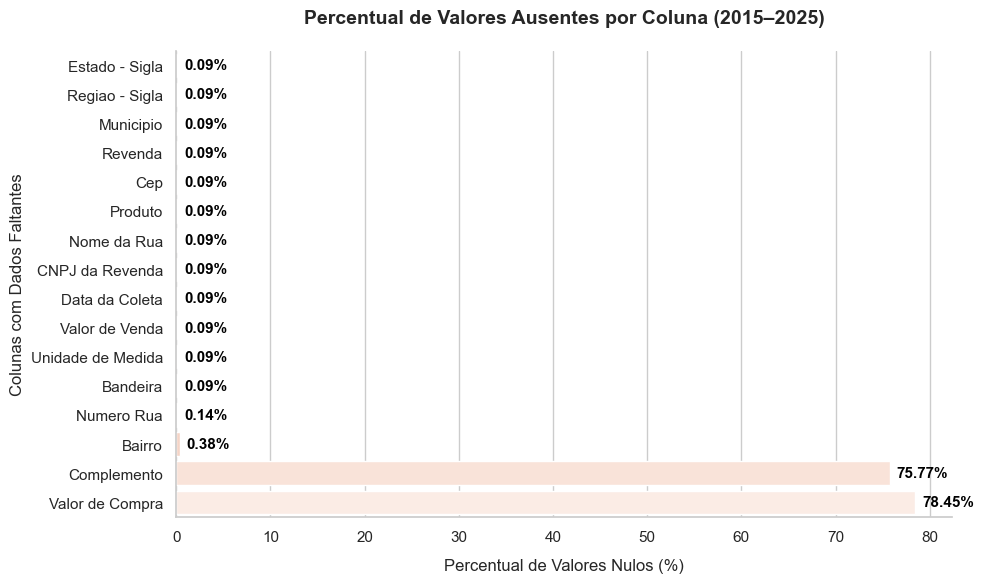

In [46]:
class AnalisadorDeQualidadeDeDados:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        sns.set_theme(style="whitegrid")

    def calcular_percentual_de_valores_ausentes(self):
        percentuais_nulos = (self.dataframe.isnull().sum() / len(self.dataframe)) * 100

        percentuais_nulos = percentuais_nulos[percentuais_nulos > 0].sort_values(ascending=False).round(2)

        return percentuais_nulos

    def plotar_grafico_de_valores_ausentes(self, percentuais_nulos: pd.Series):
        print("\n" + "-"*60)
        print(" ANÁLISE DE QUALIDADE: VALORES AUSENTES (NULOS)")
        print("-"*60 + "\n")

        if percentuais_nulos.empty:
            print("✅ Excelente! Não há valores ausentes no dataset.")
            return

        plt.figure(figsize=(10, 6))

        dados_para_plot = percentuais_nulos.sort_values(ascending=True)

        ax = sns.barplot(
            x=dados_para_plot.values,
            y=dados_para_plot.index,
            palette='Reds_r',
            hue=dados_para_plot.index,
            legend=False
        )

        for barra in ax.patches:
            ax.annotate(
                f'{barra.get_width():.2f}%',
                (barra.get_width(), barra.get_y() + barra.get_height() / 2.),
                ha='left', va='center',
                fontsize=11, color='black', fontweight='bold',
                xytext=(5, 0), textcoords='offset points' # Desloca o texto um pouco para a direita
            )

        plt.title('Percentual de Valores Ausentes por Coluna (2015–2025)', fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Percentual de Valores Nulos (%)', fontsize=12, labelpad=10)
        plt.ylabel('Colunas com Dados Faltantes', fontsize=12)

        sns.despine()
        plt.tight_layout()
        plt.show()

    def gerar_relatorio_de_qualidade_de_dados(self):
        dados_calculados = self.calcular_percentual_de_valores_ausentes()
        self.plotar_grafico_de_valores_ausentes(dados_calculados)


analisador_qualidade = AnalisadorDeQualidadeDeDados(dataframe_final)
analisador_qualidade.gerar_relatorio_de_qualidade_de_dados()

### 4.6.0 Rankin de Valores Ausentes por Coluna

Abaixo está o ranking das colunas com maior quantidade de dados faltantes, permitindo identificar quais variáveis demandam maior atenção durante o processo de tratamento e preparação dos dados.

In [47]:
import pandas as pd
from IPython.display import display

class AnalisadorTabularDeValoresAusentes:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe

    def calcular_estatisticas_de_dados_ausentes(self):
        total_de_linhas = len(self.dataframe)
        contagem_de_nulos = self.dataframe.isnull().sum()
        percentual_de_nulos = (contagem_de_nulos / total_de_linhas) * 100

        tabela_ausentes = pd.DataFrame({
            'Valores Faltantes (Qtd)': contagem_de_nulos,
            'Percentual (%)': percentual_de_nulos
        })

        tabela_ausentes = tabela_ausentes[tabela_ausentes['Valores Faltantes (Qtd)'] > 0]
        tabela_ausentes = tabela_ausentes.drop(index='Ano', errors='ignore')

        tabela_ausentes = tabela_ausentes.sort_values(by='Valores Faltantes (Qtd)', ascending=False)
        tabela_ausentes['Percentual (%)'] = tabela_ausentes['Percentual (%)'].round(2)

        return tabela_ausentes

    def exibir_relatorio_tabular(self, tabela_ausentes: pd.DataFrame):
        print("\n" + "-"*60)
        print("TABELA DETALHADA: VALORES AUSENTES POR COLUNA")
        print("-"*60 + "\n")

        if tabela_ausentes.empty:
            print("✅ O dataset está íntegro. Nenhuma das colunas originais possui valores nulos.")
        else:
            display(tabela_ausentes)

    def gerar_relatorio_completo_de_nulos(self):
        tabela_calculada = self.calcular_estatisticas_de_dados_ausentes()

        self.exibir_relatorio_tabular(tabela_calculada)

analisador_tabular_nulos = AnalisadorTabularDeValoresAusentes(dataframe_final)
analisador_tabular_nulos.gerar_relatorio_completo_de_nulos()


------------------------------------------------------------
TABELA DETALHADA: VALORES AUSENTES POR COLUNA
------------------------------------------------------------



,Valores Faltantes (Qtd),Percentual (%)
Valor de Compra,7758881,78.45
Complemento,7493123,75.77
Bairro,37430,0.38
Numero Rua,13925,0.14
Revenda,9114,0.09
Municipio,9114,0.09
Regiao - Sigla,9114,0.09
Estado - Sigla,9114,0.09
CNPJ da Revenda,9114,0.09
Nome da Rua,9114,0.09


## Conclusão - Entrega 1



- Ao longo deste notebook, foram realizadas etapas de análise exploratória e identificação de padrões relevantes no comportamento dos preços de combustíveis no Brasil.
- A partir dos resultados obtidos, foi possível compreender melhor a estrutura dos dados, suas limitações e os principais desafios envolvidos, como a presença de valores ausentes e desbalanceamentos.
- Essas análises são fundamentais para orientar as próximas etapas do projeto, especialmente no desenvolvimento de modelos preditivos mais robustos e confiáveis.

# Entrega 2 - Construção de Pipeline & Modelagem KNN

## 1.0 Importações  & Estruturação do Pipeline 

### 1.1.0 Importações

In [48]:
import itertools
import warnings

from pathlib import Path
from sklearn import set_config
set_config(transform_output="pandas")

# Pipeline, Validação e Estrutura Customizada
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.base import clone, BaseEstimator, TransformerMixin

# Tratamento de Nulos (Imputação) -> *NOVO*
from sklearn.impute import SimpleImputer, KNNImputer

# Pré-processamento e Encoding
from sklearn.preprocessing import (
    OneHotEncoder, 
    OrdinalEncoder, 
    RobustScaler, 
    MinMaxScaler, 
    QuantileTransformer, 
    FunctionTransformer
)

# Seleção de Atributos e Importância
from sklearn.feature_selection import SelectKBest, f_regression, SelectFromModel
from sklearn.inspection import permutation_importance

# Modelos
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, root_mean_squared_error, mean_absolute_error, r2_score

### 1.2.0 Construção do Pipeline & Metodologia de Testes

- Para automatizar os testes da atividade, desenvolvemos uma arquitetura orientada a objetos usando um gerenciador de pipelines. Utilizei a classe Pipeline do Scikit-Learn para encadear as etapas de pré-processamento (imputação, normalização e seleção) junto com o modelo KNN. Isso foi essencial para evitar data leakage, garantindo que as transformações fossem ajustadas apenas nos dados de treino e aplicadas corretamente nos dados de teste durante a validação cruzada.

- Para testar todas as combinações possíveis de técnicas, implementei um método baseado em produto cartesiano **(itertools.product)**. Assim, consigo gerar automaticamente diferentes configurações de pipeline, incluindo o baseline (sem técnicas). Quando não aplico alguma etapa, utilizo 'passthrough', permitindo avaliar o impacto individual de cada técnica.

- Como o KNN ($k=7$) tem alto custo computacional e a base da ANP de 2015 a 2024 é muito grande, utilizamos amostragem estratificada. Dessa forma, reduzi o dataset (por exemplo, para 50 mil linhas), mas mantendo a proporção das classes da variável Produto. Isso garante testes mais rápidos sem perder a representatividade estatística dos dados.

In [49]:
class CarregadorDeDataset:
    def __init__(self, caminho_do_arquivo: str):
        self.caminho_do_arquivo = Path(caminho_do_arquivo)

    def carregar_dados_brutos(self) -> pd.DataFrame:
        print("\n" + "-"*60)
        print("CARREGANDO DATASET ORIGINAL (ENTREGA 1)")
        print("-"*60)
        if not self.caminho_do_arquivo.exists():
            raise FileNotFoundError(f"Arquivo não encontrado: {self.caminho_do_arquivo}")
        
        dataframe_bruto = pd.read_csv(self.caminho_do_arquivo, sep=';', low_memory=False)
        print(f"✅ Total de linhas originais: {len(dataframe_bruto)}")
        return dataframe_bruto

class FormatadorDeDados:
    def converter_valor_de_venda_de_texto_para_decimal(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        dataframe['Valor de Venda'] = dataframe['Valor de Venda'].str.replace(',', '.').astype(float)
        return dataframe

class PipelineDePreparacaoDeDados:
    def __init__(self, carregador: CarregadorDeDataset, formatador: FormatadorDeDados):
        self.carregador = carregador
        self.formatador = formatador

    def executar_preparacao(self) -> pd.DataFrame:
        dados_brutos = self.carregador.carregar_dados_brutos()
        dados_formatados = self.formatador.converter_valor_de_venda_de_texto_para_decimal(dados_brutos)
        return dados_formatados

class GerenciadorDePipelines:
    def __init__(self, dataframe_preparado: pd.DataFrame):
        self.dataset = dataframe_preparado
        self.dataset_amostra = None
        self.pipelines_gerados = []

    def gerar_amostra_estratificada(self, tamanho_amostra: int = 50000):
        print(f"Gerando amostra estratificada de {tamanho_amostra} linhas...")
        if len(self.dataset) > tamanho_amostra:
            self.dataset_amostra = (
                self.dataset
                .groupby('Produto', group_keys=False)
                .apply(lambda x: x.sample(
                    int(np.rint(tamanho_amostra * len(x) / len(self.dataset))), 
                    random_state=42
                ))
            ).copy()
        else:
            self.dataset_amostra = self.dataset.copy()
        print(f"✅ Amostra pronta: {self.dataset_amostra.shape}")
        return self.dataset_amostra

    def construir_pipelines(self, dicionario_tecnicas: dict):
        print("\n" + "-"*60)
        print(" GERANDO MALHA DE PIPELINES")
        print("-"*60)
        
        chaves = dicionario_tecnicas.keys()
        valores = dicionario_tecnicas.values()
        combinacoes = [dict(zip(chaves, comb)) for comb in itertools.product(*valores)]
        
        self.pipelines_gerados = []
        for idx, comb in enumerate(combinacoes):
            etapas = []
            for nome, tecnica in comb.items():
                etapas.append((nome, tecnica if tecnica is not None else 'passthrough'))
            
            self.pipelines_gerados.append((f"Pipeline_{idx+1:02d}", Pipeline(etapas)))
            
        print(f"✅ Foram gerados {len(self.pipelines_gerados)} pipelines (incluindo o Baseline).")
        return self.pipelines_gerados

# EXECUÇÃO 
caminho_dataset = 'data/Dataset_Completo_2015_2025.csv'

carregador = CarregadorDeDataset(caminho_dataset)
formatador = FormatadorDeDados()
pipeline_etl = PipelineDePreparacaoDeDados(carregador, formatador)
df_final = pipeline_etl.executar_preparacao()

gerenciador = GerenciadorDePipelines(df_final)
df_modelagem = gerenciador.gerar_amostra_estratificada(50000)

def aplicar_interpolacao(X):
    X = X.copy()
    colunas_numericas = X.select_dtypes(include=['number']).columns
    X[colunas_numericas] = X[colunas_numericas].interpolate()
    return X

experimentos = {
    'imputacao': [FunctionTransformer(aplicar_interpolacao), None], 
    'normalizacao': [RobustScaler(), MinMaxScaler(), QuantileTransformer(), None],
    'selecao': [SelectKBest(score_func=f_regression, k=5), SelectFromModel(RandomForestRegressor(n_estimators=50)), None],
    'regressor': [KNeighborsRegressor(n_neighbors=7)] 
}

lista_pipelines = gerenciador.construir_pipelines(experimentos)


------------------------------------------------------------
CARREGANDO DATASET ORIGINAL (ENTREGA 1)
------------------------------------------------------------
✅ Total de linhas originais: 9889848
Gerando amostra estratificada de 50000 linhas...
✅ Amostra pronta: (49953, 15)

------------------------------------------------------------
 GERANDO MALHA DE PIPELINES
------------------------------------------------------------
✅ Foram gerados 24 pipelines (incluindo o Baseline).


### 1.3.0 Preparação de Dados e Redução de Dimensionalidade

 Antes de enviar os dados para os pipelines do Scikit-Learn, criamos uma classe intermediária para preparar o dataframe de modelagem. Nessa etapa, temos três pontos principais para viabilizar o uso do KNN:

1. Foi feita uma redução de dimensionalidade inicial, removendo colunas que não agregam valor preditivo (como CNPJ, razão social e endereço). Mantive apenas variáveis relevantes como região, município, produto e valor, o que também ajuda a reduzir o consumo de memória durante os testes.

2. Depois, tratamos variáveis temporais. Como o KNN não trabalha diretamente com dados do tipo datetime, converteu a data em componentes numéricos (ano e mês), eliminando a coluna original.

3. Por fim, aplicando uma amostragem estratificada dupla. Como a base é muito grande, reduziu para cerca de 5% dos dados, mas garantindo que a proporção fosse preservada tanto por produto quanto por região. Isso evita viés na amostra e garante que o modelo não fique desbalanceado, especialmente favorecendo regiões com mais dados, como o Sudeste.

In [50]:
class PreparadorDeDataframeModelagem:

    COLUNAS_RELEVANTES = [
        'Regiao - Sigla',
        'Estado - Sigla',
        'Municipio',
        'Produto',
        'Unidade de Medida',
        'Bandeira',
        'Data da Coleta',
        'Valor de Venda',
        'Valor de Compra',
    ]

    def __init__(self, dataframe: pd.DataFrame, frac_amostra: float = 0.05, seed: int = 42):
        self.dataframe = dataframe.copy()
        self.frac_amostra = frac_amostra
        self.seed = seed

    def _selecionar_colunas(self, df: pd.DataFrame) -> pd.DataFrame:
        print("⚙️ Reduzindo dimensionalidade...")
        colunas_existentes = [c for c in self.COLUNAS_RELEVANTES if c in df.columns]
        return df[colunas_existentes].copy()

    def _extrair_features_temporais(self, df: pd.DataFrame) -> pd.DataFrame:
        print("⚙️ Features: Convertendo Datas para Ano e Mês numéricos...")
        # A data é convertida e as linhas que falharem (NaT) são limpas imediatamente
        df['Data da Coleta'] = pd.to_datetime(df['Data da Coleta'], errors='coerce', format='%d/%m/%Y')
        df = df.dropna(subset=['Data da Coleta'])
        
        # O modelo KNN precisa de números, então Ano e Mês viram inteiros
        df['Ano'] = df['Data da Coleta'].dt.year
        df['Mes'] = df['Data da Coleta'].dt.month
        
        return df.drop(columns=['Data da Coleta'])

    def _amostrar_estratificado(self, df: pd.DataFrame) -> pd.DataFrame:
        print(f"Executando Amostragem Duplamente Estratificada (Produto + Região) a {self.frac_amostra*100}%...")
        amostras = []
        
        # Agrupa pelos dois eixos mais importantes para manter a integridade socioeconômica
        for _, grupo in df.groupby(['Produto', 'Regiao - Sigla']):
            tamanho_grupo = len(grupo)
            n_amostras = max(1, int(tamanho_grupo * self.frac_amostra)) 
            
            amostra = grupo.sample(n=n_amostras, random_state=self.seed)
            amostras.append(amostra)
            
        return pd.concat(amostras).reset_index(drop=True)

    def preparar(self) -> pd.DataFrame:
        print("\n" + "-"*70)
        print("PREPARANDO DATASET PARA MODELAGEM")
        print("-"*70)
        
        df = self._selecionar_colunas(self.dataframe)
        df = self._extrair_features_temporais(df)
        df = self._amostrar_estratificado(df)
        
        print(f"\n✅ Dataframe de Modelagem pronto para o KNN: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
        return df

preparador = PreparadorDeDataframeModelagem(df_final, frac_amostra=0.05)
df_modelo = preparador.preparar()

display(df_modelo.head(3))


----------------------------------------------------------------------
PREPARANDO DATASET PARA MODELAGEM
----------------------------------------------------------------------
⚙️ Reduzindo dimensionalidade...
⚙️ Features: Convertendo Datas para Ano e Mês numéricos...
Executando Amostragem Duplamente Estratificada (Produto + Região) a 5.0%...

✅ Dataframe de Modelagem pronto para o KNN: 494,020 linhas × 10 colunas


,Regiao - Sigla,Estado - Sigla,Municipio,Produto,Unidade de Medida,Bandeira,Valor de Venda,Valor de Compra,Ano,Mes
0,CO,GO,GOIANIA,DIESEL,R$ / litro,RAIZEN,2.899,NaN,2015,7
1,CO,GO,ANAPOLIS,DIESEL,R$ / litro,PETROBRAS DISTRIBUIDORA S.A.,2.949,NaN,2015,12
2,CO,GO,ITUMBIARA,DIESEL,R$ / litro,BRANCA,3.490,NaN,2018,3


### 1.4.0 Tratamento de Valores Ausentes

De forma geral, utilizamos duas estratégias complementares para tratar valores ausentes. Primeiro, remoção de  colunas com muitos dados faltantes para evitar introduzir viés artificial no modelo. Depois, para variáveis relevantes, utilizamos interpolação linear, preservando o comportamento temporal dos dados.

Com isso, equilibramos a redução de ruído (eliminando variáveis problemáticas) e preservação de informação (estimando valores de forma coerente), garantindo dados mais confiáveis para o treinamento do modelo.

#### 1.4.1 Técnica 1: Remoção de Colunas

- Para tratar valores ausentes, utilizamos como primeira abordagem a remoção de colunas com muitos dados faltantes. Quando uma variável possui uma alta proporção de nulos (acima de 30%), aplicar imputação pode gerar um viés artificial, prejudicando principalmente modelos como o KNN, que são sensíveis à distribuição dos dados.

- Para implementar isso corretamente, foi criado um transformador personalizado compatível com o Scikit-Learn. No método fit, calculando a proporção de valores nulos apenas nos dados de treino, evitando data leakage durante a validação cruzada.

- Além disso, definimos um conjunto de colunas protegidas, garantindo que variáveis importantes (como localização e a variável alvo) não sejam removidas, mesmo que apresentem valores ausentes. Isso mantém a integridade estrutural e o valor preditivo do modelo.

In [51]:
class RemovadorDeColunasPorNulos(BaseEstimator, TransformerMixin):

    COLUNAS_PROTEGIDAS = [
        'Regiao - Sigla', 'Estado - Sigla', 'Municipio',
        'Produto', 'Unidade de Medida', 'Bandeira',
        'Valor de Venda', 'Ano', 'Mes',
    ]

    def __init__(self, limiar_percentual: float = 30.0, verbose: bool = False):
        self.limiar_percentual = limiar_percentual
        self.verbose = verbose
        self.colunas_removidas_ = []

    def fit(self, X: pd.DataFrame, y=None):
        # Aprende quais colunas ultrapassam o limiar de nulos nos dados de treino.
        percentuais = (X.isnull().sum() / len(X)) * 100
        candidatas = percentuais[percentuais > self.limiar_percentual].index.tolist()
        
        # Filtra protegendo as variáveis vitais de negócio
        self.colunas_removidas_ = [c for c in candidatas if c not in self.COLUNAS_PROTEGIDAS]
        
        return self 

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:

        # Aplica a remoção das colunas previamente aprendidas.
        X_transf = X.copy()
        
        colunas_para_remover = [c for c in self.colunas_removidas_ if c in X_transf.columns]
        X_transf = X_transf.drop(columns=colunas_para_remover)

        if self.verbose:
            print("\n" + "─" * 70)
            print(" 📈 TÉCNICA 1: REMOÇÃO DE COLUNAS COM EXCESSO DE NULOS")
            print("─" * 70)
            print(f" Limiar de corte definido: {self.limiar_percentual}%")

            if colunas_para_remover:
                percentuais_atuais = (X.isnull().sum() / len(X)) * 100
                print(f" Colunas removidas ({len(colunas_para_remover)}):")
                for col in colunas_para_remover:
                    print(f"   ✗ '{col}' → {percentuais_atuais[col]:.2f}% de nulos")
            else:
                print(" Nenhuma coluna não-protegida ultrapassou o limiar estipulado.")

            nulos_restantes = X_transf.isnull().sum().sum()
            print(f"\n Nulos restantes na base: {nulos_restantes:,}")
            print(f" Shape resultante: {X_transf.shape[0]:,} linhas × {X_transf.shape[1]} colunas")
            print(f" Colunas preservadas: {X_transf.columns.tolist()}")

        return X_transf

removador = RemovadorDeColunasPorNulos(limiar_percentual=30.0, verbose=True)
df_sem_colunas_nulas = removador.fit_transform(df_modelo)


──────────────────────────────────────────────────────────────────────
 📈 TÉCNICA 1: REMOÇÃO DE COLUNAS COM EXCESSO DE NULOS
──────────────────────────────────────────────────────────────────────
 Limiar de corte definido: 30.0%
 Colunas removidas (1):
   ✗ 'Valor de Compra' → 78.42% de nulos

 Nulos restantes na base: 0
 Shape resultante: 494,020 linhas × 9 colunas
 Colunas preservadas: ['Regiao - Sigla', 'Estado - Sigla', 'Municipio', 'Produto', 'Unidade de Medida', 'Bandeira', 'Valor de Venda', 'Ano', 'Mes']


#### 1.4.2 Técnica 2: Interpolação Linear

- Como segunda abordagem para tratar valores ausentes, foi utilizado a interpolação linear, considerando que a base da ANP se comporta como uma série temporal. Nesse contexto, usar média ou mediana global poderia distorcer os dados, principalmente por conta de variações ao longo do tempo, como inflação.

- A interpolação resolve isso ao ordenar os dados por ano e mês e estimar os valores faltantes com base nos pontos vizinhos, mantendo uma progressão coerente dos preços ao longo do tempo.

- Para garantir compatibilidade com os pipelines do Scikit-Learn e evitar data leakage, implementamos essa lógica dentro de um transformador personalizado. Assim, a interpolação é feita separadamente em cada conjunto de treino e teste durante a validação cruzada, mantendo a consistência dos dados e melhorando a qualidade das entradas para o KNN.

In [52]:
class InterpoladorLinearTempo(BaseEstimator, TransformerMixin):

    def __init__(self, colunas_temporais: list = None, verbose: bool = False):
        self.colunas_temporais = colunas_temporais if colunas_temporais is not None else ['Ano', 'Mes']
        self.verbose = verbose

    def fit(self, X: pd.DataFrame, y=None):
        # Como a interpolação é baseada nos vizinhos da própria sequência, não há parâmetros globais para aprender no fit.
        return self 

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        df_resultado = X.copy()

        # 1. Ordenação temporal obrigatória para a interpolação fazer sentido
        colunas_ordenacao = [c for c in self.colunas_temporais if c in df_resultado.columns]
        if colunas_ordenacao:
            df_resultado = df_resultado.sort_values(by=colunas_ordenacao).reset_index(drop=True)

        # 2. Identifica apenas as colunas numéricas que possuem buracos
        numericas = df_resultado.select_dtypes(include=[np.number]).columns.tolist()
        alvos = [c for c in numericas if df_resultado[c].isnull().any()]

        # 3. Aplica a interpolação
        for col in alvos:
            df_resultado[col] = df_resultado[col].interpolate(method='linear', limit_direction='both')

        if self.verbose:
            print("\n" + "─" * 70)
            print(" 📈 TÉCNICA 2: IMPUTAÇÃO POR INTERPOLAÇÃO LINEAR (SÉRIE TEMPORAL)")
            print("─" * 70)

            if not alvos:
                print(" ✅ Nenhuma coluna numérica com valores ausentes foi encontrada.")
            else:
                for col in alvos:
                    nulos_antes = X[col].isnull().sum()
                    nulos_depois = df_resultado[col].isnull().sum()
                    print(f"\n 📊 Coluna '{col}':")
                    print(f"   → Nulos originais : {nulos_antes:,}")
                    print(f"   → Nulos pós-imputação: {nulos_depois:,}")

            nulos_totais = df_resultado.isnull().sum().sum()
            print(f"\n Total de nulos restantes no dataset: {nulos_totais:,}")
            print(f" Shape resultante: {df_resultado.shape[0]:,} linhas × {df_resultado.shape[1]} colunas")

        return df_resultado

interpolador = InterpoladorLinearTempo(verbose=True)

df_sem_nulos = interpolador.fit_transform(df_sem_colunas_nulas)


──────────────────────────────────────────────────────────────────────
 📈 TÉCNICA 2: IMPUTAÇÃO POR INTERPOLAÇÃO LINEAR (SÉRIE TEMPORAL)
──────────────────────────────────────────────────────────────────────
 ✅ Nenhuma coluna numérica com valores ausentes foi encontrada.

 Total de nulos restantes no dataset: 0
 Shape resultante: 494,020 linhas × 9 colunas


### 1.5.0 Encoding

- De forma geral, utilizamos duas estratégias de encoding com objetivos diferentes. O **Ordinal Encoding** foi aplicado como uma solução mais simples e eficiente em termos de memória, servindo como baseline, apesar de poder introduzir relações artificiais entre categorias.

- Já o **One-Hot Encoding** foi utilizado para representar corretamente variáveis categóricas sem criar hierarquia entre elas, sendo mais adequado para o KNN, mesmo com o custo de aumentar a dimensionalidade dos dados.

- Com isso, comparamos na prática o impacto de cada abordagem e escolher a que oferece melhor desempenho para o modelo.

#### 1.5.1 Técnica 1: Ordinal Encoding

- Para transformar variáveis categóricas em valores numéricos, utilizamos o **Ordinal Encoding**, aplicado nas variáveis independentes. Essa etapa é necessária porque o KNN calcula distâncias euclidianas e não consegue trabalhar diretamente com dados em formato de texto.

- Para evitar problemas durante a validação cruzada, configuramos o encoder com `handle_unknown='use_encoded_value'`. Assim, quando aparece uma categoria no conjunto de teste que não estava no treino, ela recebe o valor -1, evitando erros e mantendo a consistência do pipeline.

- Do ponto de vista crítico, nossa hipótese é que essa técnica, apesar de ser eficiente em termos de memória, pode prejudicar o desempenho do KNN. Isso acontece porque o modelo passa a interpretar uma **ordem numérica artificial** entre categorias que, na prática, não possuem relação de hierarquia.

- Por exemplo, ao codificar cidades como números inteiros, o modelo pode inferir distâncias inexistentes entre elas, o que impacta diretamente no cálculo dos vizinhos mais próximos. Por isso, foi utilizado abordagem principalmente como baseline, para comparar com técnicas mais robustas e validar esse efeito na prática.

In [53]:
class CodificadorOrdinalNativo(BaseEstimator, TransformerMixin):

    def __init__(self, colunas_alvo: list = None, verbose: bool = False):
        self.colunas_alvo = colunas_alvo if colunas_alvo is not None else ['Municipio', 'Bandeira', 'Estado - Sigla']
        self.verbose = verbose
        
        # Atribuímos o valor -1 para o modelo saber que é algo desconhecidoo.
        self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1)
        self.colunas_efetivas_ = []

    def fit(self, X: pd.DataFrame, y=None):
        # Aprende o dicionário de categorias -> números apenas nos dados de treino
        self.colunas_efetivas_ = [c for c in self.colunas_alvo if c in X.columns]
        
        if self.colunas_efetivas_:
            # Treina o encoder para mapear os nomes para números
            self.encoder.fit(X[self.colunas_efetivas_].astype(str))
            
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_transf = X.copy()

        if self.colunas_efetivas_:
            X_transf[self.colunas_efetivas_] = self.encoder.transform(X_transf[self.colunas_efetivas_].astype(str))

        if self.verbose:
            print("\n" + "─" * 70)
            print(" 🔍 TÉCNICA 1 DE ENCODING: ORDINAL ENCODING (LABEL ENCODING)")
            print("─" * 70)
            
            for i, col in enumerate(self.colunas_efetivas_):
                n_classes = len(self.encoder.categories_[i])
                print(f"\n 📊 Coluna '{col}':")
                print(f"   → Categorias únicas mapeadas: {n_classes:,}")
                print(f"   → Formato resultante: {X_transf[col].dtype}")
                exemplo_categorias = self.encoder.categories_[i][:4].tolist()
                exemplo_numeros = list(range(len(exemplo_categorias)))
                print(f"   → Exemplo de Mapeamento: {exemplo_categorias} ➔ {exemplo_numeros}")

            print(f"\n Shape final após Encoding: {X_transf.shape[0]:,} linhas × {X_transf.shape[1]} colunas")

        return X_transf

codificador_ordinal = CodificadorOrdinalNativo(verbose=True)

df_encoded_1 = codificador_ordinal.fit_transform(df_sem_nulos)


──────────────────────────────────────────────────────────────────────
 🔍 TÉCNICA 1 DE ENCODING: ORDINAL ENCODING (LABEL ENCODING)
──────────────────────────────────────────────────────────────────────

 📊 Coluna 'Municipio':
   → Categorias únicas mapeadas: 592
   → Formato resultante: float64
   → Exemplo de Mapeamento: ['ABAETETUBA', 'ABREU E LIMA', 'ACAILANDIA', 'ADAMANTINA'] ➔ [0, 1, 2, 3]

 📊 Coluna 'Bandeira':
   → Categorias únicas mapeadas: 112
   → Formato resultante: float64
   → Exemplo de Mapeamento: ['ACOL', 'AGIP DISTRIBUIDORA', 'AIR BP', 'ALE'] ➔ [0, 1, 2, 3]

 📊 Coluna 'Estado - Sigla':
   → Categorias únicas mapeadas: 27
   → Formato resultante: float64
   → Exemplo de Mapeamento: ['AC', 'AL', 'AM', 'AP'] ➔ [0, 1, 2, 3]

 Shape final após Encoding: 494,020 linhas × 9 colunas


#### 1.5.2 Técnica 2: One-Hot Encoding

- Para variáveis categóricas de baixa e média cardinalidade, como produto, região e unidade de medida, utilizamos o One-Hot Encoding. 

- Isso é especialmente importante para o KNN, pois garante que todas as categorias sejam tratadas como equidistantes no espaço vetorial, melhorando a qualidade do cálculo dos vizinhos mais próximos.

- Para implementar essa abordagem, foi tuilizado o OneHotEncoder do Scikit-Learn em vez do get_dummies do Pandas. Essa escolha foi essencial para manter a consistência durante a validação cruzada, já que o encoder do Scikit-Learn garante que o conjunto de colunas permaneça fixo entre treino e teste.

In [54]:
class CodificadorOneHotNativo(BaseEstimator, TransformerMixin):

    def __init__(self, colunas_alvo: list = None, drop_first: bool = True, verbose: bool = False):
        self.colunas_alvo = colunas_alvo if colunas_alvo is not None else ['Produto', 'Regiao - Sigla', 'Unidade de Medida']
        self.drop_first = drop_first
        self.verbose = verbose
        
        param_drop = 'first' if self.drop_first else None
        self.encoder = OneHotEncoder(drop=param_drop, sparse_output=False, handle_unknown='ignore')
        
        self.colunas_efetivas_ = []
        self.nomes_features_geradas_ = []

    def fit(self, X: pd.DataFrame, y=None):
    # Aprende quais são as categorias únicas presentes nos dados de TREINO.
        self.colunas_efetivas_ = [c for c in self.colunas_alvo if c in X.columns]
        
        if self.colunas_efetivas_:
            self.encoder.fit(X[self.colunas_efetivas_].astype(str))
            # Guarda os nomes das novas colunas (Ex: Produto_Gasolina, Regiao_SE)
            self.nomes_features_geradas_ = self.encoder.get_feature_names_out(self.colunas_efetivas_)
            
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:

        X_transf = X.copy()

        if not self.colunas_efetivas_:
            return X_transf
        
        # Aplica a transformação
        dados_codificados = self.encoder.transform(X_transf[self.colunas_efetivas_].astype(str))
        
        if not isinstance(dados_codificados, pd.DataFrame):
            dados_codificados = pd.DataFrame(
                dados_codificados, 
                columns=self.nomes_features_geradas_, 
                index=X_transf.index
            )

        # Remove as colunas originais de texto e acopla as novas colunas numéricas
        X_transf = X_transf.drop(columns=self.colunas_efetivas_)
        X_transf = pd.concat([X_transf, dados_codificados], axis=1)

        if self.verbose:
            print("\n" + "─" * 70)
            print(" 🔍 TÉCNICA 2 DE ENCODING: ONE-HOT ENCODING ")
            print("─" * 70)
            
            for col in self.colunas_efetivas_:
                novas_cols = [c for c in self.nomes_features_geradas_ if c.startswith(col)]
                print(f"\n 📊 Coluna original '{col}':")
                print(f"   → Transformada em {len(novas_cols)} novas colunas booleanas.")
                print(f"   → Exemplo: {novas_cols[:3]}")

            print(f"\n Total de colunas geradas: {len(self.nomes_features_geradas_)}")
            print(f" Shape final após Encoding: {X_transf.shape[0]:,} linhas × {X_transf.shape[1]} colunas")

        return X_transf

one_hot_encoder = CodificadorOneHotNativo(drop_first=True, verbose=True)

df_encoded_completo = one_hot_encoder.fit_transform(df_encoded_1)



──────────────────────────────────────────────────────────────────────
 🔍 TÉCNICA 2 DE ENCODING: ONE-HOT ENCODING 
──────────────────────────────────────────────────────────────────────

 📊 Coluna original 'Produto':
   → Transformada em 5 novas colunas booleanas.
   → Exemplo: ['Produto_DIESEL S10', 'Produto_ETANOL', 'Produto_GASOLINA']

 📊 Coluna original 'Regiao - Sigla':
   → Transformada em 4 novas colunas booleanas.
   → Exemplo: ['Regiao - Sigla_N', 'Regiao - Sigla_NE', 'Regiao - Sigla_S']

 📊 Coluna original 'Unidade de Medida':
   → Transformada em 2 novas colunas booleanas.
   → Exemplo: ['Unidade de Medida_R$ / m3', 'Unidade de Medida_R$ / m³']

 Total de colunas geradas: 11
 Shape final após Encoding: 494,020 linhas × 17 colunas


### 1.6.0 Normalização dos Dados

- Nesta etapa, aplicamos diferentes técnicas de normalização para garantir que todas as variáveis numéricas contribuam de forma equilibrada no cálculo de distância do KNN. Como esse algoritmo é baseado em distância euclidiana, diferenças de escala entre variáveis podem distorcer completamente os resultados.

- Para isso, utilizamos três abordagens com objetivos complementares: o Robust Scaler, mais resistente a outliers; o MinMax Scaler, que padroniza os dados em um intervalo fixo entre 0 e 1; e o Quantile Transformer, que redistribui os dados de forma não linear para reduzir o impacto de valores extremos.

#### 1.6.1 Técnica 1: Robust Scaler

- Para padronizar a escala das variáveis, utilizamos o Robust Scaler. Como o KNN calcula distâncias no espaço euclidiano, variáveis com magnitudes muito diferentes podem distorcer esse cálculo. Por exemplo, uma variável como ano pode acabar tendo muito mais influência do que mês apenas por ter valores maiores.

- O Robust Scaler resolve isso ao centralizar os dados na mediana e escalonar pelo intervalo interquartil (IQR), o que o torna mais resistente a outliers. Essa escolha foi importante porque os dados da ANP apresentam variações econômicas relevantes, e não queriamos que valores extremos distorcessem o comportamento geral dos dados.

- A normalização foi aplicada apenas nas variáveis preditoras (X), utilizando o Scikit-Learn, mantendo a variável alvo (valor de venda) na escala original. Isso garante que as métricas finais, como erro, continuem interpretáveis.


──────────────────────────────────────────────────────────────────────
 🔍 TÉCNICA 1 DE NORMALIZAÇÃO: ROBUST SCALER (RESISTENTE A OUTLIERS)
──────────────────────────────────────────────────────────────────────
 📊 Coluna 'Ano': Mediana aprendida = 2020.00 | IQR (escala) = 6.00
 📊 Coluna 'Mes': Mediana aprendida = 6.00 | IQR (escala) = 6.00


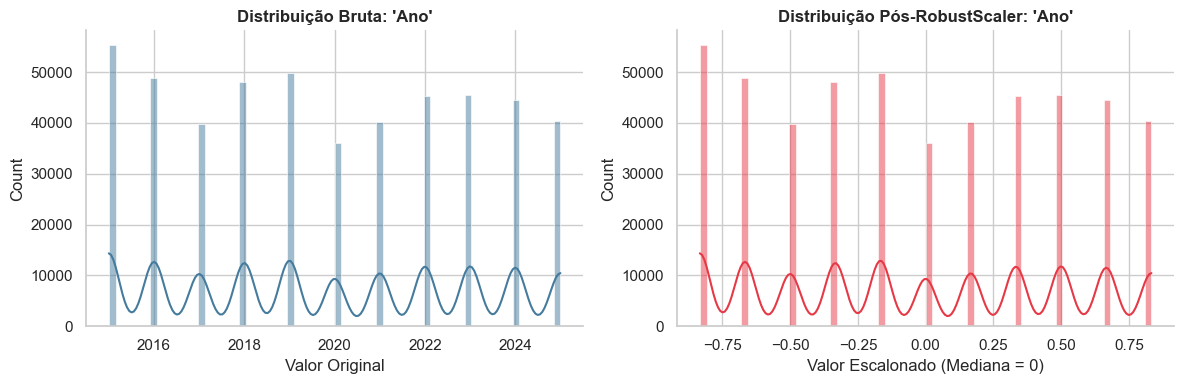

In [55]:
class ScalerRobustNativo(BaseEstimator, TransformerMixin):

    def __init__(self, colunas_numericas_continuas: list = None, verbose: bool = False):
        # Escala apenas colunas numéricas que têm grandeza real (ex: Ano, Mes)
        self.colunas_numericas_continuas = colunas_numericas_continuas if colunas_numericas_continuas is not None else ['Ano', 'Mes']
        self.verbose = verbose
        self.scaler = RobustScaler()
        self.colunas_efetivas_ = []

    def fit(self, X: pd.DataFrame, y=None):
        self.colunas_efetivas_ = [c for c in self.colunas_numericas_continuas if c in X.columns]
        
        if self.colunas_efetivas_:
            self.scaler.fit(X[self.colunas_efetivas_])
            
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_transf = X.copy()

        if self.colunas_efetivas_:
            X_transf[self.colunas_efetivas_] = self.scaler.transform(X_transf[self.colunas_efetivas_])

        if self.verbose and self.colunas_efetivas_:
            print("\n" + "─" * 70)
            print(" 🔍 TÉCNICA 1 DE NORMALIZAÇÃO: ROBUST SCALER (RESISTENTE A OUTLIERS)")
            print("─" * 70)
            
            for i, col in enumerate(self.colunas_efetivas_):
                print(f" 📊 Coluna '{col}': Mediana aprendida = {self.scaler.center_[i]:.2f} | IQR (escala) = {self.scaler.scale_[i]:.2f}")
            
            col_plot = self.colunas_efetivas_[0] # Pega a primeira coluna para dar o exemplo visual
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            sns.histplot(X[col_plot].dropna(), ax=axes[0], kde=True, color='#457B9D')
            axes[0].set_title(f"Distribuição Bruta: '{col_plot}'", fontweight='bold')
            axes[0].set_xlabel('Valor Original')

            sns.histplot(X_transf[col_plot].dropna(), ax=axes[1], kde=True, color='#E63946')
            axes[1].set_title(f"Distribuição Pós-RobustScaler: '{col_plot}'", fontweight='bold')
            axes[1].set_xlabel('Valor Escalonado (Mediana = 0)')

            sns.despine()
            plt.tight_layout()
            plt.show()

        return X_transf

colunas_continuas_independentes = ['Ano', 'Mes']
robust_scaler = ScalerRobustNativo(colunas_numericas_continuas=colunas_continuas_independentes, verbose=True)

df_robust = robust_scaler.fit_transform(df_encoded_completo)

#### 1.6.2 Técnica 2: MinMaxScaler

- Como segunda abordagem de normalização, o MinMax Scaler, que transforma os dados para um intervalo fixo entre 0 e 1. Isso garante que todas as variáveis tenham a mesma escala, evitando que atributos com valores maiores dominem o cálculo de distância no KNN.

- Do ponto de vista crítico, a hipótese é que o MinMax Scaler pode ter um desempenho inferior ao Robust Scaler neste cenário. Isso porque ele é muito sensível a outliers: valores extremos acabam definindo os limites da escala, o que pode “achatar” a maior parte dos dados em uma faixa muito próxima de zero.

- Como os dados da ANP apresentam variações econômicas relevantes e possíveis valores discrepantes, essa sensibilidade pode prejudicar a qualidade das distâncias calculadas pelo KNN. Por isso, utilizei essa técnica principalmente para comparação experimental com o Robust Scaler.


──────────────────────────────────────────────────────────────────────
 🔍 TÉCNICA 2 DE NORMALIZAÇÃO: MIN-MAX SCALER (0, 1)
──────────────────────────────────────────────────────────────────────
 📊 Coluna 'Ano': Mínimo original = 2015.00 | Máximo original = 2025.00
 📊 Coluna 'Mes': Mínimo original = 1.00 | Máximo original = 12.00


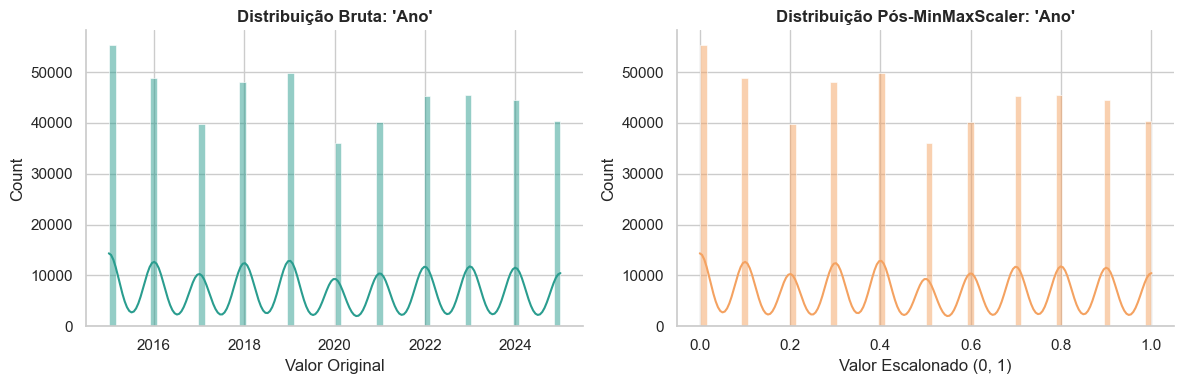

In [56]:
class ScalerMinMaxNativo(BaseEstimator, TransformerMixin):

    def __init__(self, colunas_numericas_continuas: list = None, feature_range: tuple = (0, 1), verbose: bool = False):
        self.colunas_numericas_continuas = colunas_numericas_continuas if colunas_numericas_continuas is not None else ['Ano', 'Mes']
        self.feature_range = feature_range
        self.verbose = verbose
        
        self.scaler = MinMaxScaler(feature_range=self.feature_range)
        self.colunas_efetivas_ = []

    def fit(self, X: pd.DataFrame, y=None):
        # Descobre o valor Mínimo e Máximo absoluto de cada coluna nos dados de TREINO.
        self.colunas_efetivas_ = [c for c in self.colunas_numericas_continuas if c in X.columns]
        
        if self.colunas_efetivas_:
            self.scaler.fit(X[self.colunas_efetivas_])
            
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        # Aplica a fórmula: (X - min) / (max - min)
        X_transf = X.copy()

        if self.colunas_efetivas_:
            X_transf[self.colunas_efetivas_] = self.scaler.transform(X_transf[self.colunas_efetivas_])

        if self.verbose and self.colunas_efetivas_:
            print("\n" + "─" * 70)
            print(f" 🔍 TÉCNICA 2 DE NORMALIZAÇÃO: MIN-MAX SCALER {self.feature_range}")
            print("─" * 70)
            
            for i, col in enumerate(self.colunas_efetivas_):
                print(f" 📊 Coluna '{col}': Mínimo original = {self.scaler.data_min_[i]:.2f} | Máximo original = {self.scaler.data_max_[i]:.2f}")
            
            col_plot = self.colunas_efetivas_[0] 
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            sns.histplot(X[col_plot].dropna(), ax=axes[0], kde=True, color='#2A9D8F')
            axes[0].set_title(f"Distribuição Bruta: '{col_plot}'", fontweight='bold')
            axes[0].set_xlabel('Valor Original')

            sns.histplot(X_transf[col_plot].dropna(), ax=axes[1], kde=True, color='#F4A261')
            axes[1].set_title(f"Distribuição Pós-MinMaxScaler: '{col_plot}'", fontweight='bold')
            axes[1].set_xlabel(f'Valor Escalonado {self.feature_range}')

            sns.despine()
            plt.tight_layout()
            plt.show()

        return X_transf

colunas_continuas_independentes = ['Ano', 'Mes']
minmax_scaler = ScalerMinMaxNativo(colunas_numericas_continuas=colunas_continuas_independentes, verbose=True)

df_minmax = minmax_scaler.fit_transform(df_encoded_completo)

#### 1.6.3 Técnica 3: QuantileTransformer

- Como terceira abordagem de normalização, utilizamos o Quantile Transformer, configurado para gerar uma distribuição uniforme. Diferente das técnicas anteriores, ele aplica uma transformação não linear, baseada na função de distribuição acumulada (CDF), redistribuindo os dados ao longo do intervalo entre 0 e 1.

- Na prática, isso faz com que valores mais frequentes sejam melhor distribuídos, enquanto outliers são comprimidos para as extremidades. Essa transformação pode ajudar a reduzir o impacto de valores extremos e tornar a distribuição dos dados mais homogênea.

- Do ponto de vista crítico, minha hipótese é que o Quantile Transformer pode melhorar o desempenho do KNN ao reduzir o ruído causado por outliers. Por outro lado, ele distorce as distâncias reais entre os pontos, o que pode afetar a interpretação geométrica dos dados.


──────────────────────────────────────────────────────────────────────
 🔍 TÉCNICA 3 DE NORMALIZAÇÃO: QUANTILE TRANSFORMER (UNIFORM)
──────────────────────────────────────────────────────────────────────
 📊 Número de quantis utilizados: 1000


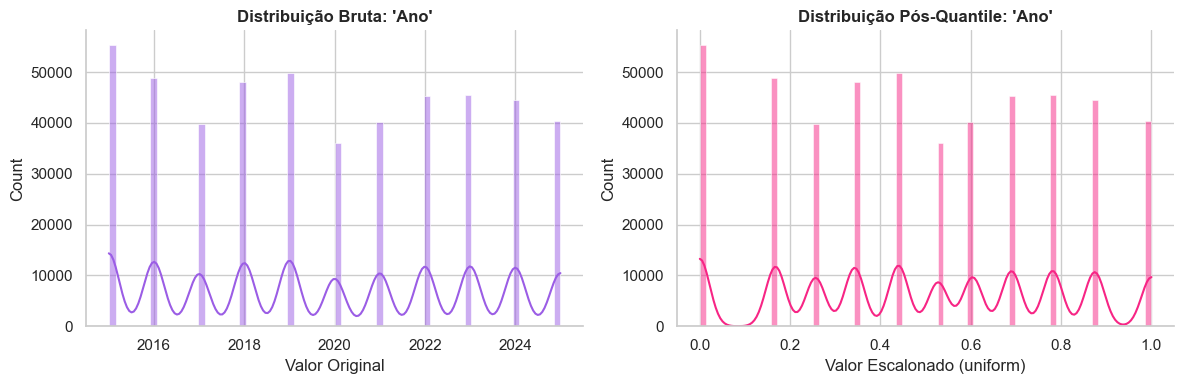

In [57]:
class ScalerQuantileNativo(BaseEstimator, TransformerMixin):

    def __init__(self, colunas_numericas_continuas: list = None, output_distribution: str = 'uniform', n_quantiles: int = 1000, verbose: bool = False):
        self.colunas_numericas_continuas = colunas_numericas_continuas if colunas_numericas_continuas is not None else ['Ano', 'Mes']
        self.output_distribution = output_distribution
        # Em bases pequenas/amostras, n_quantiles não pode ser maior que o número de linhas
        self.n_quantiles = n_quantiles 
        self.verbose = verbose
        
        self.scaler = QuantileTransformer(
            output_distribution=self.output_distribution, 
            n_quantiles=self.n_quantiles, 
            random_state=42
        )
        self.colunas_efetivas_ = []

    def fit(self, X: pd.DataFrame, y=None):
        # Calcula a Função de Distribuição Acumulada (CDF) nos dados de TREINO.
        self.colunas_efetivas_ = [c for c in self.colunas_numericas_continuas if c in X.columns]
        
        if self.colunas_efetivas_:
            n_amostras = len(X)
            if self.scaler.n_quantiles > n_amostras:
                self.scaler.set_params(n_quantiles=max(10, n_amostras // 2))
                
            self.scaler.fit(X[self.colunas_efetivas_])
            
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_transf = X.copy()

        if self.colunas_efetivas_:
            X_transf[self.colunas_efetivas_] = self.scaler.transform(X_transf[self.colunas_efetivas_])

        if self.verbose and self.colunas_efetivas_:
            print("\n" + "─" * 70)
            print(f" 🔍 TÉCNICA 3 DE NORMALIZAÇÃO: QUANTILE TRANSFORMER ({self.output_distribution.upper()})")
            print("─" * 70)
            print(f" 📊 Número de quantis utilizados: {self.scaler.n_quantiles_}")
            
            col_plot = self.colunas_efetivas_[0] 
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            sns.histplot(X[col_plot].dropna(), ax=axes[0], kde=True, color='#9B5DE5')
            axes[0].set_title(f"Distribuição Bruta: '{col_plot}'", fontweight='bold')
            axes[0].set_xlabel('Valor Original')

            sns.histplot(X_transf[col_plot].dropna(), ax=axes[1], kde=True, color='#F72585')
            axes[1].set_title(f"Distribuição Pós-Quantile: '{col_plot}'", fontweight='bold')
            axes[1].set_xlabel(f'Valor Escalonado ({self.output_distribution})')

            sns.despine()
            plt.tight_layout()
            plt.show()

        return X_transf

colunas_continuas_independentes = ['Ano', 'Mes']
quantile_scaler = ScalerQuantileNativo(colunas_numericas_continuas=colunas_continuas_independentes, verbose=True)

df_quantile = quantile_scaler.fit_transform(df_encoded_completo)

#### 1.6.4 Comparador Visual de Técnicas de Normalização

- **Dados Originais**: o gráfico apresenta os valores no formato real, com os anos variando aproximadamente entre 2015 e 2025, refletindo a escala original dos dados.

- **Robust Scaler**: visualmente, o formato da distribuição permanece praticamente o mesmo. A principal diferença é que os dados agora estão centralizados na mediana, fazendo com que o “zero” fique no meio da distribuição.

- **MinMax Scaler**: aqui, todos os valores foram comprimidos para o intervalo entre 0 e 1. Isso faz com que o eixo fique totalmente limitado nesse range, independentemente da escala original.

- **Quantile Transformer**: nesse caso, a transformação é mais agressiva. A distribuição original é alterada significativamente, deixando de ter picos naturais e passando a assumir um formato mais uniforme. Isso mostra que os dados foram redistribuídos para reduzir o impacto de concentrações e outliers.

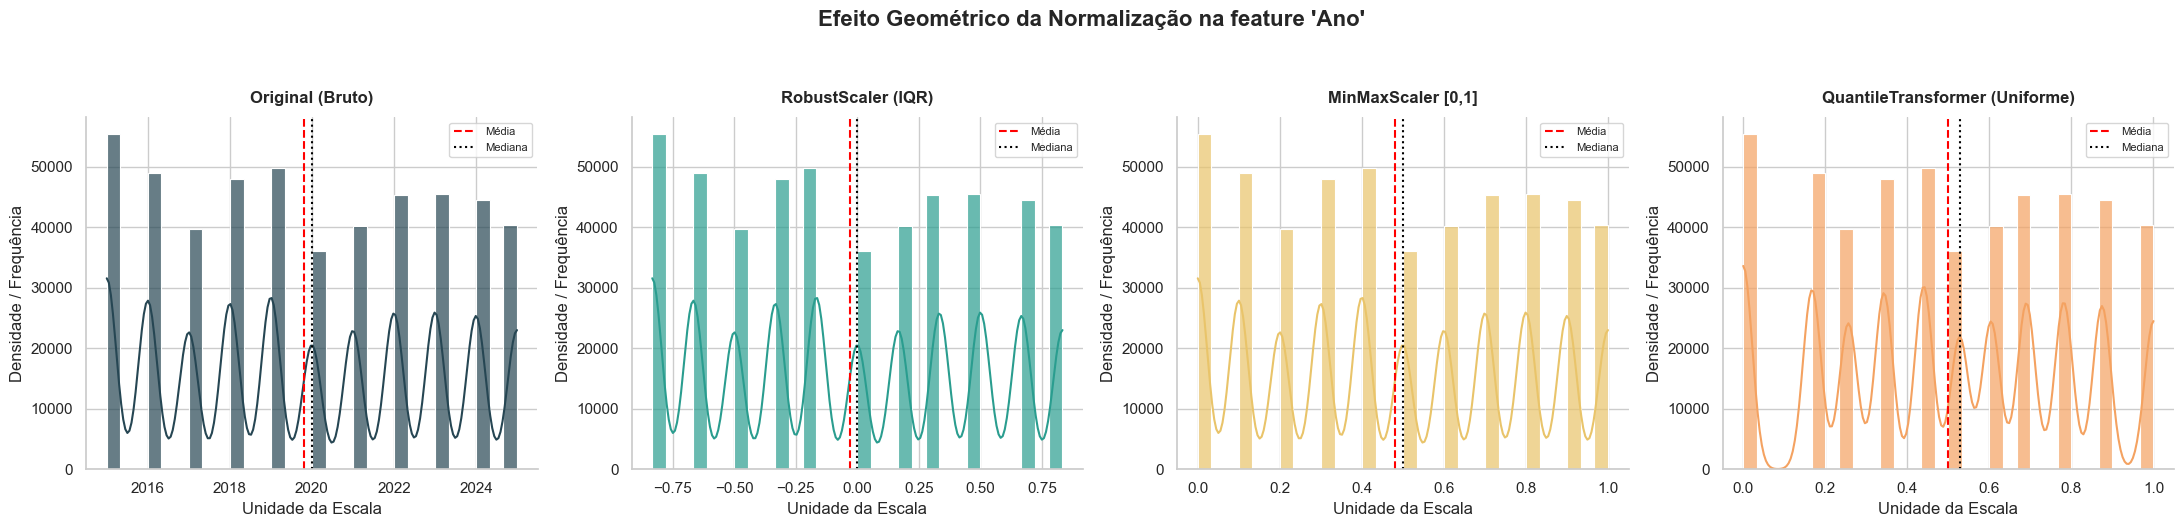

In [58]:
class ComparadorDeEscalonamentosVisual:

    def __init__(self, coluna_para_plotar: str = 'Ano'):
        self.coluna_para_plotar = coluna_para_plotar

    def plotar(
        self,
        df_original: pd.DataFrame,
        df_robust: pd.DataFrame,
        df_minmax: pd.DataFrame,
        df_quantile: pd.DataFrame
    ) -> None:
        
        frames = {
            'Original (Bruto)': df_original,
            'RobustScaler (IQR)': df_robust,
            'MinMaxScaler [0,1]': df_minmax,
            'QuantileTransformer (Uniforme)': df_quantile,
        }

        cores = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261']

        fig, axes = plt.subplots(1, 4, figsize=(22, 5))
        fig.suptitle(
            f"Efeito Geométrico da Normalização na feature '{self.coluna_para_plotar}'",
            fontsize=16, fontweight='bold', y=1.05
        )

        for ax, (titulo, df_), cor in zip(axes, frames.items(), cores):
            if self.coluna_para_plotar not in df_.columns:
                ax.text(0.5, 0.5, f"Coluna '{self.coluna_para_plotar}' não encontrada", 
                        ha='center', va='center', color='red')
                ax.axis('off')
                continue
                
            sns.histplot(df_[self.coluna_para_plotar].dropna(), ax=ax, kde=True, color=cor, bins=30, alpha=0.7)
            
            media = df_[self.coluna_para_plotar].mean()
            mediana = df_[self.coluna_para_plotar].median()
            ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label='Média')
            ax.axvline(mediana, color='black', linestyle=':', linewidth=1.5, label='Mediana')
            
            ax.set_title(titulo, fontweight='bold', pad=10)
            ax.set_xlabel('Unidade da Escala')
            ax.set_ylabel('Densidade / Frequência')
            ax.legend(fontsize=8)
            sns.despine(ax=ax)

        plt.tight_layout()
        plt.show()

comparador_visual = ComparadorDeEscalonamentosVisual(coluna_para_plotar='Ano')

comparador_visual.plotar(
    df_encoded_completo, # Original
    df_robust,           # Robust
    df_minmax,           # MinMax
    df_quantile          # Quantile
)

### 1.7.0 Redução / Seleção de Atributos

- Nesta etapa, aplicamos duas estratégias de redução e seleção de atributos para mitigar a maldição da dimensionalidade e melhorar o desempenho do KNN, principalmente após o aumento de colunas gerado pelo One-Hot Encoding.

- A primeira abordagem foi um filtro híbrido, onde removemos variáveis altamente correlacionadas e, em seguida, selecionei as mais relevantes com o SelectKBest. Essa técnica é mais simples, rápida e fácil de interpretar, mas avalia cada variável de forma isolada.

- Já a segunda abordagem utilizou Feature Importance com Random Forest, permitindo capturar relações não lineares e interações entre variáveis. Com isso, Consegumos eliminar atributos pouco relevantes de forma mais inteligente, gerando um conjunto de dados mais otimizado.

#### 1.7.1 Técnica 1: Matriz de Correlação & SelectKBest

- Para reduzir a dimensionalidade dos dados, usamos uma estratégia híbrida de seleção de atributos. Isso foi necessário porque o KNN perde desempenho em espaços com muitas variáveis, problema conhecido como maldição da dimensionalidade, que se intensificou após o uso de One-Hot Encoding.

- A abordagem foi dividida em duas fases. Primeiro, removi variáveis altamente correlacionadas (Cor > 0.90), eliminando redundâncias e reduzindo multicolinearidade. Em seguida, foi aplicado o SelectKBest com a função *f_regression*, utilizando o Scikit-Learn para selecionar as variáveis com maior relevância estatística em relação ao preço do combustível.

- Do ponto de vista crítico, essa técnica tem baixo custo computacional e é fácil de interpretar, pois é possível identificar claramente quais variáveis foram selecionadas. Por outro lado, a hipótese é que ela pode deixar passar relações mais complexas, já que avalia cada variável de forma isolada e não considera interações entre elas.


──────────────────────────────────────────────────────────────────────
 🔍 TÉCNICA 1 DE REDUÇÃO: CORRELAÇÃO + SELECTKBEST (Top 10)
──────────────────────────────────────────────────────────────────────

 [Passo 1] Multicolinearidade (Limiar 0.9):
   🚫 Removidas: ['Unidade de Medida_R$ / m³']

 [Passo 2] SelectKBest aplicou corte. Features mantidas (10):
   ✅ ['Estado - Sigla', 'Bandeira', 'Ano', 'Mes', 'Produto_ETANOL', 'Produto_GASOLINA', 'Produto_GASOLINA ADITIVADA', 'Produto_GNV', 'Regiao - Sigla_N', 'Regiao - Sigla_SE']


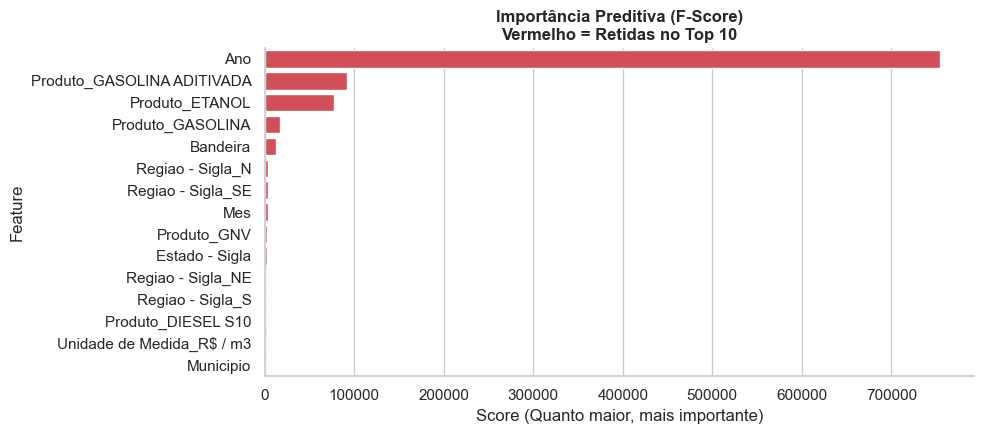

In [59]:
class SeletorKBestCorrelacaoNativo(BaseEstimator, TransformerMixin):

    def __init__(self, limiar_correlacao: float = 0.90, k_melhores: int = 10, verbose: bool = False):
        self.limiar_correlacao = limiar_correlacao
        self.k_melhores = k_melhores
        self.verbose = verbose
        
        # Variáveis de estado aprendidas durante o fit
        self.colunas_removidas_por_correlacao_ = []
        self.features_selecionadas_ = []
        self.selector_ = None

    def fit(self, X: pd.DataFrame, y=None):
        
        # Aprende a matriz de correlação e o F-score (SelectKBest) usando os dados de TREINO.
        if y is None:
            raise ValueError("O alvo 'y' deve ser fornecido na etapa fit para o SelectKBest.")

        # Passo 1: Remoção de Multicolinearidade (Correlação X com X)
        matriz_corr = X.corr(numeric_only=True).abs()
        triangulo_superior = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
        
        self.colunas_removidas_por_correlacao_ = [
            col for col in triangulo_superior.columns
            if any(triangulo_superior[col] > self.limiar_correlacao)
        ]
        
        X_sem_redundantes = X.drop(columns=self.colunas_removidas_por_correlacao_)

        # Passo 2: SelectKBest (Correlação X com y) 
        k_real = min(self.k_melhores, X_sem_redundantes.shape[1])
        self.selector_ = SelectKBest(score_func=f_regression, k=k_real)
        
        # Treina o seletor
        self.selector_.fit(X_sem_redundantes, y)
        
        self.features_selecionadas_ = X_sem_redundantes.columns[self.selector_.get_support()].tolist()

        if self.verbose:
            self.scores_df_ = pd.DataFrame({
                'Feature': X_sem_redundantes.columns,
                'F-Score': self.selector_.scores_,
                'p-valor': self.selector_.pvalues_
            }).sort_values('F-Score', ascending=False)

        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:

        # Aplica a seleção: filtra o DataFrame original mantendo apenas as colunas 'vitoriosas'.
        colunas_vitoriosas = [c for c in self.features_selecionadas_ if c in X.columns]
        X_transf = X[colunas_vitoriosas].copy()

        if self.verbose:
            print("\n" + "─" * 70)
            print(f" 🔍 TÉCNICA 1 DE REDUÇÃO: CORRELAÇÃO + SELECTKBEST (Top {self.k_melhores})")
            print("─" * 70)
            
            print(f"\n [Passo 1] Multicolinearidade (Limiar {self.limiar_correlacao}):")
            if self.colunas_removidas_por_correlacao_:
                print(f"   🚫 Removidas: {self.colunas_removidas_por_correlacao_}")
            else:
                print("   ✅ Nenhuma redundância colinear detectada.")

            print(f"\n [Passo 2] SelectKBest aplicou corte. Features mantidas ({len(colunas_vitoriosas)}):")
            print(f"   ✅ {colunas_vitoriosas}")

            plt.figure(figsize=(10, max(4, len(self.scores_df_) * 0.3)))
            cores_barras = ['#E63946' if f in self.features_selecionadas_ else '#ADB5BD' for f in self.scores_df_['Feature']]
            
            ax = sns.barplot(data=self.scores_df_, x='F-Score', y='Feature', hue='Feature', palette=cores_barras, legend=False)
            ax.set_title(f'Importância Preditiva (F-Score)\nVermelho = Retidas no Top {self.k_melhores}', fontweight='bold')
            ax.set_xlabel('Score (Quanto maior, mais importante)')
            sns.despine()
            plt.tight_layout()
            plt.show()

        return X_transf

y = df_encoded_completo['Valor de Venda']  # A nossa variável alvo intocada
X = df_minmax.drop(columns=['Valor de Venda']) # Todo o resto normalizado

seletor_kbest = SeletorKBestCorrelacaoNativo(limiar_correlacao=0.90, k_melhores=10, verbose=True)
X_selecionado = seletor_kbest.fit_transform(X, y)

#### 1.7.2 Técnica 2: Feature Importance & Random Forest

- Como segunda abordagem de seleção de atributos, utilizamos a importância de variáveis gerada por um modelo de Random Forest. Diferente do método anterior, essa técnica consegue capturar relações não lineares e interações entre múltiplas variáveis, tornando a seleção mais robusta.

- Durante o treinamento (fase de fit), o modelo avalia o quanto cada variável contribui para reduzir o erro de predição. Com base nisso, eu defini um limiar mínimo de importância (0.001), removendo variáveis que praticamente não contribuem para explicar o valor de venda.

- A hipótese é que essa abordagem tende a gerar um conjunto de dados mais relevante e otimizado para o KNN. Ao remover variáveis irrelevantes, o modelo passa a calcular distâncias com base apenas em informações realmente importantes, o que pode melhorar significativamente o desempenho preditivo (como RMSE e MAE).


──────────────────────────────────────────────────────────────────────
 🔍 TÉCNICA 2 DE REDUÇÃO: FEATURE IMPORTANCE (RANDOM FOREST)
──────────────────────────────────────────────────────────────────────
 Limiar de corte: 0.1%
 Features retidas: 11 de 16


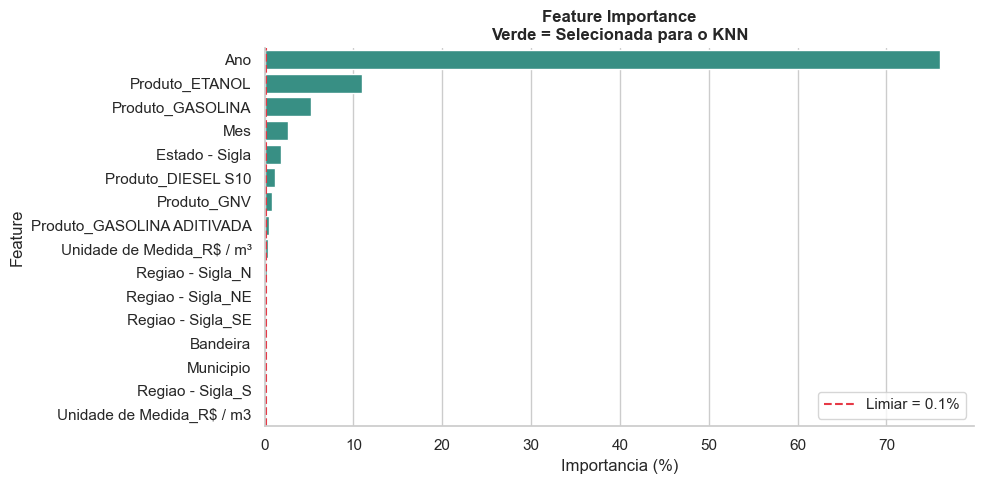

In [60]:
class SeletorRandomForestNativo(BaseEstimator, TransformerMixin):

    def __init__(self, limiar_importancia: float = 0.001, n_estimators: int = 100, max_depth: int = 8, seed: int = 42, verbose: bool = False):
        self.limiar_importancia = limiar_importancia
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.seed = seed
        self.verbose = verbose
        
        self.features_selecionadas_ = []
        self.importancias_df_ = None

    def fit(self, X: pd.DataFrame, y=None):
        
        # Treina o Random Forest nos dados de TREINO e calcula a importância relativa.
        if y is None:
            raise ValueError("O alvo 'y' é obrigatório para treinar o Random Forest.")

        modelo = RandomForestRegressor(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            random_state=self.seed,
            n_jobs=-1 # Usa todos os núcleos do processador para ser rápido
        )
        modelo.fit(X, y)

        # Extrai e ordena as importâncias
        self.importancias_df_ = pd.DataFrame({
            'Feature': X.columns,
            'Importancia': modelo.feature_importances_
        }).sort_values('Importancia', ascending=False).reset_index(drop=True)
        
        self.importancias_df_['Importancia (%)'] = (self.importancias_df_['Importancia'] * 100).round(2)

        # Filtra as features que superam o limiar
        self.features_selecionadas_ = self.importancias_df_[
            self.importancias_df_['Importancia'] >= self.limiar_importancia
        ]['Feature'].tolist()

        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        colunas_vitoriosas = [c for c in self.features_selecionadas_ if c in X.columns]
        X_transf = X[colunas_vitoriosas].copy()

        if self.verbose:
            print("\n" + "─" * 70)
            print(f" 🔍 TÉCNICA 2 DE REDUÇÃO: FEATURE IMPORTANCE (RANDOM FOREST)")
            print("─" * 70)
            print(f" Limiar de corte: {self.limiar_importancia * 100:.1f}%")
            print(f" Features retidas: {len(colunas_vitoriosas)} de {X.shape[1]}")
            
            df_plot = self.importancias_df_.copy()
            df_plot['Selecionada'] = df_plot['Feature'].isin(self.features_selecionadas_)

            plt.figure(figsize=(10, max(5, len(df_plot) * 0.3)))
            cores_barras = ['#2A9D8F' if s else '#ADB5BD' for s in df_plot['Selecionada']]
            
            ax = sns.barplot(data=df_plot, x='Importancia (%)', y='Feature', palette=cores_barras, hue='Feature', legend=False)
            ax.axvline(x=self.limiar_importancia * 100, color='#E63946', linestyle='--', linewidth=1.5, label=f'Limiar = {self.limiar_importancia*100:.1f}%')
            
            ax.set_title('Feature Importance\nVerde = Selecionada para o KNN', fontweight='bold')
            ax.legend(loc='lower right')
            sns.despine()
            plt.tight_layout()
            plt.show()

        return X_transf

seletor_rf = SeletorRandomForestNativo(limiar_importancia=0.001, n_estimators=100, verbose=True)

X_selecionado_t2 = seletor_rf.fit_transform(X, y)

#### 1.7.3 Comparação de Técnicas de Seleção

──────────────────────────────────────────────────────────────────────
 🔍 COMPARATIVO: SELECT_K_BEST vs RANDOM_FOREST
──────────────────────────────────────────────────────────────────────

 [T1] Correlação + SelectKBest    : 10 features selecionadas
 [T2] Feature Importance (RF)     : 11 features selecionadas

 ✅ Concordância (em ambas)        : ['Ano', 'Estado - Sigla', 'Mes', 'Produto_ETANOL', 'Produto_GASOLINA', 'Produto_GASOLINA ADITIVADA', 'Produto_GNV', 'Regiao - Sigla_N']
 ℹ️  Apenas no SelectKBest (T1)    : ['Bandeira', 'Regiao - Sigla_SE']
 ℹ️  Apenas no Random Forest (T2)  : ['Produto_DIESEL S10', 'Regiao - Sigla_NE', 'Unidade de Medida_R$ / m³']


<Figure size 1200x685 with 0 Axes>

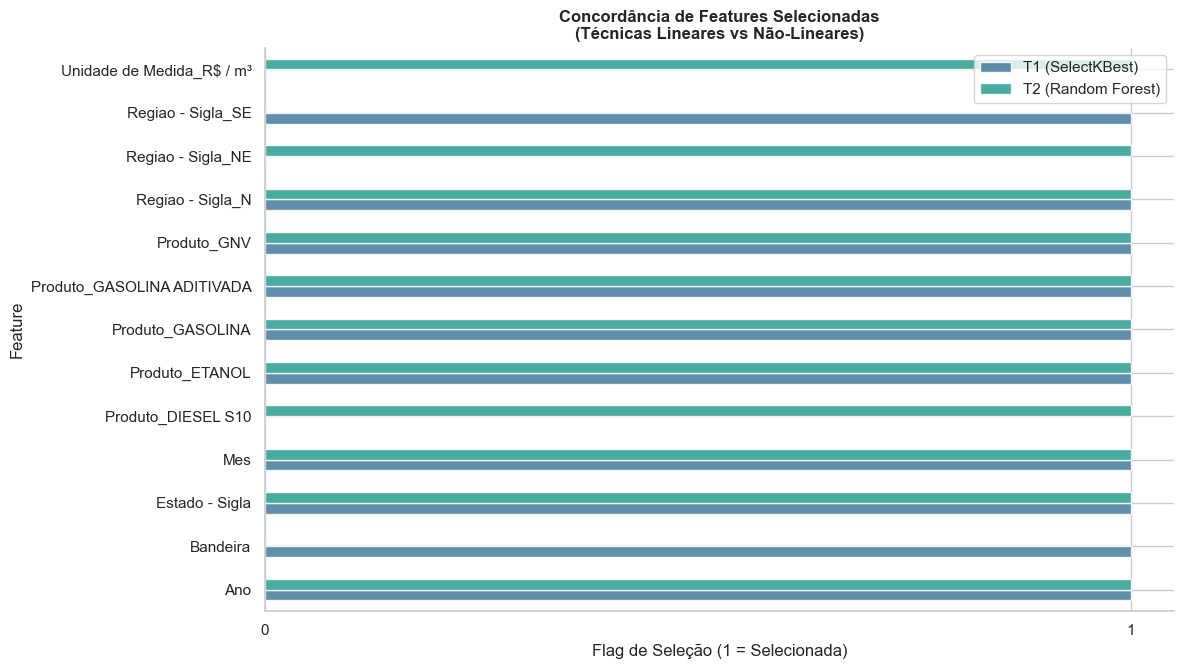

In [61]:
class ComparadorDeTecnicasDeSelecaoVisual:

    def __init__(self, seletor_t1: SeletorKBestCorrelacaoNativo, seletor_t2: SeletorRandomForestNativo):
        self.t1_features = set(seletor_t1.features_selecionadas_)
        self.t2_features = set(seletor_t2.features_selecionadas_)

    def gerar_relatorio(self) -> None:
        concordancia   = self.t1_features & self.t2_features
        apenas_t1      = self.t1_features - self.t2_features
        apenas_t2      = self.t2_features - self.t1_features
        uniao          = self.t1_features | self.t2_features

        print("─" * 70)
        print(" 🔍 COMPARATIVO: SELECT_K_BEST vs RANDOM_FOREST")
        print("─" * 70)

        print(f"\n [T1] Correlação + SelectKBest    : {len(self.t1_features)} features selecionadas")
        print(f" [T2] Feature Importance (RF)     : {len(self.t2_features)} features selecionadas")
        
        print(f"\n ✅ Concordância (em ambas)        : {sorted(concordancia)}")
        print(f" ℹ️  Apenas no SelectKBest (T1)    : {sorted(apenas_t1)}")
        print(f" ℹ️  Apenas no Random Forest (T2)  : {sorted(apenas_t2)}")

        if not uniao:
            print("\n Nenhuma feature foi selecionada por nenhuma técnica.")
            return

        # Diagrama de Barras
        df_comp = pd.DataFrame({
            'Feature': sorted(uniao),
            'T1 (SelectKBest)': [1 if f in self.t1_features else 0 for f in sorted(uniao)],
            'T2 (Random Forest)' : [1 if f in self.t2_features else 0 for f in sorted(uniao)],
        }).set_index('Feature')

        plt.figure(figsize=(12, max(5, len(df_comp) * 0.45 + 1)))
        
        ax = df_comp.plot(
            kind='barh', figsize=(12, max(5, len(df_comp) * 0.45 + 1)),
            color=['#457B9D', '#2A9D8F'], edgecolor='white', alpha=0.85
        )
        
        ax.set_title('Concordância de Features Selecionadas\n(Técnicas Lineares vs Não-Lineares)', fontweight='bold')
        ax.set_xlabel('Flag de Seleção (1 = Selecionada)')
        ax.set_xticks([0, 1])
        sns.despine()
        plt.tight_layout()
        plt.show()

comparador_selecao = ComparadorDeTecnicasDeSelecaoVisual(seletor_kbest, seletor_rf)
comparador_selecao.gerar_relatorio()

## 2.0 Modelagem do KNN

- Para avaliar o impacto das diferentes combinações de pré-processamento, foi utilizado validação cruzada 5-Fold, garantindo uma análise mais robusta e generalizável do desempenho do modelo.

- Como o objetivo era testar todas as combinações possíveis, incluindo o baseline (sem aplicação de técnicas), foi implementado uma abordagem de programação defensiva com try/except. Isso foi necessário porque algumas combinações são naturalmente inválidas. Por exemplo, ao não aplicar encoding, variáveis categóricas em formato de texto são passadas diretamente para o KNN, o que gera erro, já que o algoritmo trabalha com dados numéricos.

- Nesses casos, o sistema captura a falha e classifica como uma incompatibilidade geométrica, seguindo automaticamente para a próxima combinação. Dessa forma, consigo garantir que apenas pipelines válidos sejam considerados na análise final.

- Ao final, o relatório apresenta métricas como RMSE, MAE e $R^2$ (média e desvio padrão) apenas para as combinações viáveis.

- Como resultado, nosso algoritmo consegue prever o preço de qualquer combustível (Gasolina, Etanol, Diesel, GNV), em qualquer lugar do Brasil, errando em média apenas R$0,56 centavos. Considerando que estamos prevendo uma década inteira (entre 2015 a 2025), mesmo com Crise econômica no Brasil em 2016, Greve dos caminhoneiros em 2018, Pandemia da COVID-19 em 2020 e Alta global dos combustíveis em 2022. O que acarretou em preços muitos diferentes, essa é uma taxa de acerto boa para um modelo.


Verificando integridade da variável alvo...

⚙️ Iniciando bateria de testes com 24 pipelines gerados...
 🔍 [24/24] Avaliando Pipeline_24...
 Todos os experimentos foram concluídos!

----------------------------------------------------------------------------------------------------
 🔍 RANKING DOS MELHORES PIPELINES (Ordenado pelo menor RMSE)
----------------------------------------------------------------------------------------------------


,Pipeline,RMSE (Média),RMSE (Desvio Padrão),MAE (Média),MAE (Desvio Padrão),R2 (Média),R2 (Desvio Padrão),Status
0,Pipeline_01,0.5648,0.1725,0.4087,0.1327,0.7631,0.1357,✅ Sucesso
1,Pipeline_13,0.5648,0.1725,0.4087,0.1327,0.7631,0.1357,✅ Sucesso
2,Pipeline_16,0.5776,0.2128,0.4241,0.1570,0.7562,0.1425,✅ Sucesso
3,Pipeline_04,0.5776,0.2128,0.4241,0.1570,0.7562,0.1425,✅ Sucesso
4,Pipeline_10,0.6509,0.1578,0.4667,0.1177,0.7095,0.1088,✅ Sucesso
5,Pipeline_22,0.6509,0.1578,0.4667,0.1177,0.7095,0.1088,✅ Sucesso
6,Pipeline_07,0.6552,0.2839,0.4890,0.2120,0.6776,0.2190,✅ Sucesso
7,Pipeline_19,0.6562,0.2857,0.4897,0.2130,0.6763,0.2210,✅ Sucesso
8,Pipeline_05,0.6573,0.2865,0.4920,0.2345,0.5495,0.5637,✅ Sucesso
9,Pipeline_17,0.6573,0.2865,0.4920,0.2345,0.5495,0.5637,✅ Sucesso


Gerando visualização de performance...


C:\Users\lucas\AppData\Local\Temp\ipykernel_4436\1765430939.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


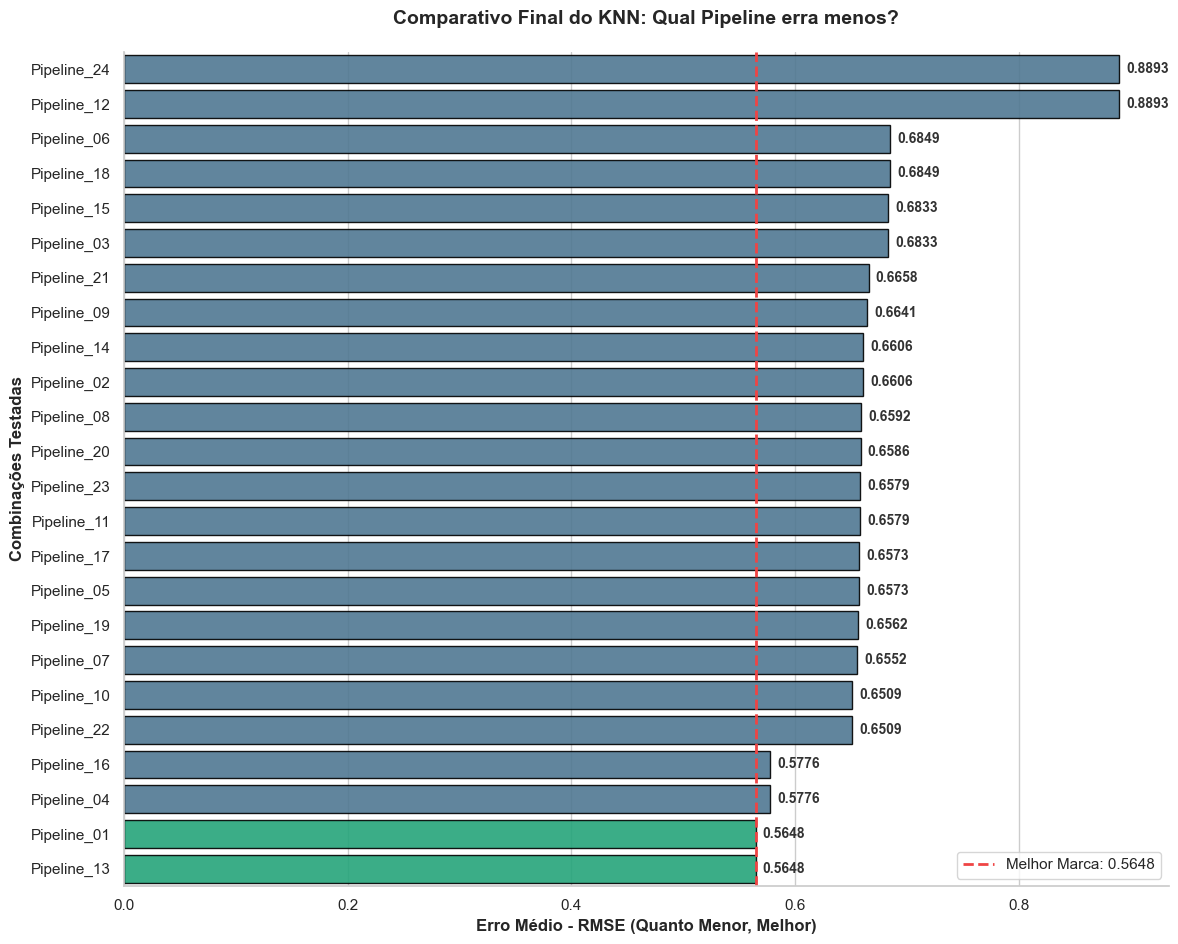

In [62]:
class ModeloKNN:
    def __init__(self, k=7):
        self.k = k

    def criar_modelo(self):
        return KNeighborsRegressor(n_neighbors=self.k, n_jobs=-1)

class AvaliadorDeModelos:
    def __init__(self, cv=5):
        self.cv = cv
        
        # Cria as métricas exigidas
        self.metricas = {
            'RMSE': make_scorer(root_mean_squared_error),
            'MAE': make_scorer(mean_absolute_error),
            'R2': make_scorer(r2_score)
        }

    def avaliar(self, pipeline, X, y):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            scores = cross_validate(
                pipeline, X, y, cv=self.cv,
                scoring=self.metricas, return_train_score=False,
                n_jobs=None
            )

        resultados = {}
        for chave in scores:
            if "test" in chave:
                nome_limpo = chave.replace("test_", "")
                resultados[nome_limpo] = {
                    "media": scores[chave].mean(),
                    "std": scores[chave].std()
                }

        return resultados

class ExecutorDeExperimentosSeguro:
    def __init__(self, avaliador: AvaliadorDeModelos):
        self.avaliador = avaliador
        self.resultados = []

    def executar(self, pipelines: dict, X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
        total = len(pipelines)
        print(f"\n⚙️ Iniciando bateria de testes com {total} pipelines gerados...")
        
        for i, (nome, pipeline) in enumerate(pipelines.items()):
            print(f" 🔍 [{i+1}/{total}] Avaliando {nome}...", end="\r")
            
            registro = {"Pipeline": nome}
            
            try:
                resultado = self.avaliador.avaliar(pipeline, X, y)
                
                for metrica, valores in resultado.items():
                    # Arredonda para 4 casas decimais
                    registro[f"{metrica} (Média)"] = round(valores["media"], 4)
                    registro[f"{metrica} (Desvio Padrão)"] = round(valores["std"], 4)
                    
                registro["Status"] = "✅ Sucesso"
                
            except Exception as e:
                tipo_erro = e.__class__.__name__
                erro_msg = str(e).split('\n')[0] 
                registro["Status"] = f"❌ {tipo_erro}: {erro_msg}"
                
            self.resultados.append(registro)

        print("\n Todos os experimentos foram concluídos!")
        return pd.DataFrame(self.resultados)

print("\nVerificando integridade da variável alvo...")
df_modelo_limpo = df_modelo.dropna(subset=['Valor de Venda']).copy()

cols_texto = df_modelo_limpo.select_dtypes(include=['object', 'string']).columns
df_modelo_limpo[cols_texto] = df_modelo_limpo[cols_texto].fillna("Desconhecido")
df_modelo_seguro = df_modelo.copy()

# 1. Garante que o Alvo é 100% numérico 
df_modelo_seguro['Valor de Venda'] = pd.to_numeric(
    df_modelo_seguro['Valor de Venda'].astype(str).str.replace(',', '.'), 
    errors='coerce'
)
df_modelo_seguro = df_modelo_seguro.dropna(subset=['Valor de Venda'])
cols_texto = df_modelo_seguro.select_dtypes(include=['object', 'string']).columns
for col in cols_texto:
    # pd.factorize converte categorias em números
    df_modelo_seguro[col] = pd.factorize(df_modelo_seguro[col])[0]

y_final = df_modelo_seguro['Valor de Venda']
X_final = df_modelo_seguro.drop(columns=['Valor de Venda'])

pipelines_dict = {nome: pipe for nome, pipe in lista_pipelines}
avaliador = AvaliadorDeModelos(cv=5)
executor = ExecutorDeExperimentosSeguro(avaliador)

# Vai rodar o 5-fold 
df_resultados_finais = executor.executar(pipelines_dict, X_final, y_final)

print("\n" + "-" * 100)
print(" 🔍 RANKING DOS MELHORES PIPELINES (Ordenado pelo menor RMSE)")
print("-" * 100)

if 'RMSE (Média)' in df_resultados_finais.columns:
    df_sucessos = df_resultados_finais[df_resultados_finais['Status'] == '✅ Sucesso']
    df_ranking = df_sucessos.sort_values(by='RMSE (Média)').reset_index(drop=True)
    display(df_ranking.head(10))
    
    df_falhas = df_resultados_finais[df_resultados_finais['Status'] != '✅ Sucesso']
    if not df_falhas.empty:
        print("\n⚠️ Pipelines com incompatibilidade teórica:")
        display(df_falhas[['Pipeline', 'Status']].head())
else:
    print("🚨 Falha Crítica. Verifique o dataset original.")
    
import matplotlib.pyplot as plt
import seaborn as sns


# GRÁFICO DE PERFORMANCE DOS PIPELINES
print("Gerando visualização de performance...")

# 1. Filtramos apenas os que deram Sucesso e ordenamos do pior pro melhor (para o melhor ficar no topo do gráfico)
df_plot = df_resultados_finais[df_resultados_finais['Status'] == '✅ Sucesso'].copy()
df_plot = df_plot.sort_values('RMSE (Média)', ascending=False) 

if df_plot.empty:
    print("Nenhum gráfico gerado pois todos os pipelines falharam.")
else:
    # 2. Configuração do Canvas (Tamanho dinâmico baseado na quantidade de pipelines)
    plt.figure(figsize=(12, max(6, len(df_plot) * 0.4)))
    sns.set_theme(style="whitegrid")

    # 3. Inteligência de Cores (O melhor pipeline ganha cor de destaque - Verde)
    melhor_rmse = df_plot['RMSE (Média)'].min()
    cores = ['#10B981' if rmse == melhor_rmse else '#457B9D' for rmse in df_plot['RMSE (Média)']]

    # 4. Plotagem da Barra
    ax = sns.barplot(
        data=df_plot, 
        x='RMSE (Média)', 
        y='Pipeline', 
        palette=cores,
        edgecolor='black',
        alpha=0.9
    )

    # 5. Colocando os rótulos numéricos na ponta de cada barra
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.4f}', 
                    (width, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', 
                    xytext=(5, 0), textcoords='offset points',
                    fontweight='bold', color='#333333', fontsize=10)

    # 6. Adicionando Títulos e a Linha do Campeão
    plt.title('Comparativo Final do KNN: Qual Pipeline erra menos?', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Erro Médio - RMSE (Quanto Menor, Melhor)', fontsize=12, fontweight='bold')
    plt.ylabel('Combinações Testadas', fontsize=12, fontweight='bold')
    
    # Linha vertical marcando a pontuação do vencedor
    plt.axvline(x=melhor_rmse, color='#EF4444', linestyle='--', linewidth=2, label=f'Melhor Marca: {melhor_rmse:.4f}')
    plt.legend(loc='lower right')
    
    sns.despine()
    plt.tight_layout()
    plt.show()